# Solenoid Design-Space Study — Main Driver

Sweeps a set of solenoid lengths, builds the winding-thickness design grid for
each, and writes one long-format CSV per length for downstream plotting.

**Pipeline**

`config` → `solenoid_lib` (physics) → `grid` (mesh sweep) → `io_grids` (CSV out)
→ `plots_thickness` / `plots_area` (figures)

**Outputs:** `thickness_grids_L<length>mm.csv`, one row per (thickness, radius)
grid node, with fields `ri`, `th`, `v`, `v_bore`, `b0`, `scan`, `length_tape_km`,
`pancake_length_m` and the associated current-density and stress diagnostics.
Files are written to the kernel's working directory — in VS Code this is set by
`jupyter.notebookFileRoot` and is not necessarily this file's folder, so check
`Path.cwd()` if the analysis notebook can't find them.

**Run as a notebook or in the VS Code interactive window** — `%matplotlib widget`
is a cell magic and will not parse under `python main.py`. Interactive picking in
the plotting modules needs `ipympl` installed in the kernel's environment; if
figures come up blank, re-run the cell or switch to `%matplotlib qt`.

Modules are hot-reloaded dependency-first on every execution, so editing a
library file and re-running this cell is enough; no kernel restart needed.

> **Note:** re-running this cell rebuilds `all_grids` and rewrites the CSVs.
> Any downstream cell holding an older `df_all` must be re-run too, or it will
> silently plot stale data.

In [14]:
# # main.py
# # ─────────────────────────────────────────────────────────────────────────────
# # Orchestrates the full solenoid design-space study.
# #
# #   Run in Jupyter/IPython to utilize interactive widgets.
# # ─────────────────────────────────────────────────────────────────────────────
# %matplotlib widget

# import importlib

# # Hot-reload local modules, dependency-first, so a reloaded module never holds
# # references to a stale version of something below it.
# import config
# importlib.reload(config)

# import solenoid_lib
# importlib.reload(solenoid_lib)

# import grid
# importlib.reload(grid)

# import io_grids
# importlib.reload(io_grids)

# import plots_thickness
# importlib.reload(plots_thickness)

# import plots_area
# importlib.reload(plots_area)


# # Define the lengths (in meters) to iterate over
# LENGTHS_M = [2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0, 10.0]  # meters


# def main():
#     all_grids = {}

#     for L in LENGTHS_M:
#         print(f"\n=== Solenoid Length = {L*1e3:.0f} mm ===")

#         # 1. Update the physics library with the current length
#         solenoid_lib.solenoid_length = L
#         label = f"L{int(round(L*1e3))}mm"

#         # 2. Build the meshgrids based on Thickness
#         a_grids = grid.build_thickness_grid()

#         # 3. Save the results to the newly formatted CSV
#         csv_filename = f"thickness_grids_{label}.csv"
#         io_grids.save_grids_long(a_grids, csv_filename, solenoid_length=L)

#         # 4. Generate all the requested contour plots
#         #plots_thickness.plot_all(a_grids, label=label, solenoid_length_m=L)

#         # Store for return
#         all_grids[L] = a_grids

#     return all_grids


# if __name__ == "__main__":
#     # Run the main loop
#     all_grids = main()








# main.py

%matplotlib widget

import importlib

import numpy as np

# Hot-reload local modules, dependency-first, so a reloaded module never holds
# references to a stale version of something below it.
import config
importlib.reload(config)

import solenoid_lib
importlib.reload(solenoid_lib)

import grid
importlib.reload(grid)

print(grid.__file__)
print(hasattr(grid, "RESULT_KEYS"))
print(hasattr(solenoid_lib, "solve_design"), hasattr(solenoid_lib, "DesignParams"))

import io_grids
importlib.reload(io_grids)

import plots_thickness
importlib.reload(plots_thickness)

import plots_area
importlib.reload(plots_area)


# Define the lengths (in meters) to iterate over
LENGTHS_M = [ 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0, 10.0 ]  # meters


def main():
    all_grids = {}

    for L in LENGTHS_M:
        print(f"\n=== Solenoid Length = {L*1e3:.0f} mm ===")

        # 1. Update the physics library with the current length.
        solenoid_lib.solenoid_length = L
        config.L_COIL = L
        label = f"L{int(round(L*1e3))}mm"

        # 2. Build the meshgrids based on Thickness
        a_grids = grid.build_thickness_grid()

        # 3. Save the results to the newly formatted CSV.
        csv_filename = f"thickness_grids_{label}.csv"
        io_grids.save_grids_long(a_grids, csv_filename)

        # 4. What the quench protection costs on this map
        b0, b0m = a_grids["b0"], a_grids["b0_mech"]
        ok = np.isfinite(b0)
        if np.any(ok):
            print(f"  quench cost: median "
                  f"{100*np.nanmedian(1 - b0[ok]/b0m[ok]):.1f} % of B0, "
                  f"{np.count_nonzero(~ok & a_grids['valid'])} cells unprotectable")

        # 5. Generate all the requested contour plots
        #plots_thickness.plot_all(a_grids, label=label, solenoid_length_m=L)

        # Store for return
        all_grids[L] = a_grids

    return all_grids


if __name__ == "__main__":
    # Run the main loop
    all_grids = main()

/Users/penelopequassolo/Projects/PhD/Magnet_design/DMRadio_GUT_preliminary_design/grid.py
True
True True

=== Solenoid Length = 3000 mm ===
  length 3000.0 mm = 750 pancakes
  winding: n_par=10 tapes paralleled into one turn (1.000 mm of build per turn); L falls as 1/n_par^2 at fixed Je
[!] round_to=0.001 merged 2 of 150 points (finest step 0.000273 < round_to)
Th-scan axes:
  Ri          : 150 pts, 100.000 – 8000.000 mm, step 53.020 → 53.020 mm (coarsening) (uniform would be 53.020)
  Th          : 148 pts, 3.000 – 500.000 mm, step 1.000 → 5.000 mm (coarsening) (uniform would be 3.381)
  22200/22200  (100%)
2-D meshgrid (Th-scan) computed.

─ Th-scan summary (sigma<=750 MPa @ u=1.0, fill<=1, U_EE=1000 ohm, n_par=10, gamma_max=2.50e+16) ─
  cells in mask   : 22200 / 22200
  feasible        : 22061 / 22200   (99 %)
  binding         : mechanical 87%  packing 13%
  Ri              : 100.0 – 8000.0 mm
  Th (mm)         : 3.00 – 500.00
  B0              : 0.041 – 27.918 T
  B0 if no quench

# Detailed Parameter Maps — Contour Analysis per Solenoid Length

Loads every `thickness_grids_L*.csv` in the working directory and draws a
three-panel map of the design space for one selected solenoid length.

All panels share `Ri` (mm) on the x-axis and a filled scan-time background,
differing only in the y-quantity: coil thickness (mm), tape length per pancake
(m), and total tape length (km). Iso-lines: **B₀** (black), **scan time** (blue,
dashed), **hoop stress** (crimson, dash-dot), plus **thickness** (purple,
dotted) on panels 2 and 3. Grid nodes are drawn invisibly as pick targets —
click one for a tooltip with its full parameter set.

Values are interpolated onto a 400×400 mesh with `griddata`; blank regions are
outside the convex hull of the data, not physically excluded. Legacy `*_sc`
column names are remapped per-file before the concat and flagged with `[!]`.

Set `selected_length` in the last section to any value present in
`solenoid_length_m` (exact match required).

> Axis limits are hard-coded (0–1500 mm; 400 mm / 2500 m / 3000 km) and the
> scan-time fill is clipped at 20 yr — designs outside are silently off-screen.
> Tooltips need `%matplotlib widget` and a live kernel.

[!] thickness_grids_L10000mm.csv: legacy columns remapped (length_tape_km->length_tape_km)
[!] thickness_grids_L3000mm.csv: legacy columns remapped (length_tape_km->length_tape_km)
[!] thickness_grids_L4000mm.csv: legacy columns remapped (length_tape_km->length_tape_km)
[!] thickness_grids_L5000mm.csv: legacy columns remapped (length_tape_km->length_tape_km)
[!] thickness_grids_L6000mm.csv: legacy columns remapped (length_tape_km->length_tape_km)
[!] thickness_grids_L7000mm.csv: legacy columns remapped (length_tape_km->length_tape_km)
[!] thickness_grids_L8000mm.csv: legacy columns remapped (length_tape_km->length_tape_km)
[!] thickness_grids_L9000mm.csv: legacy columns remapped (length_tape_km->length_tape_km)


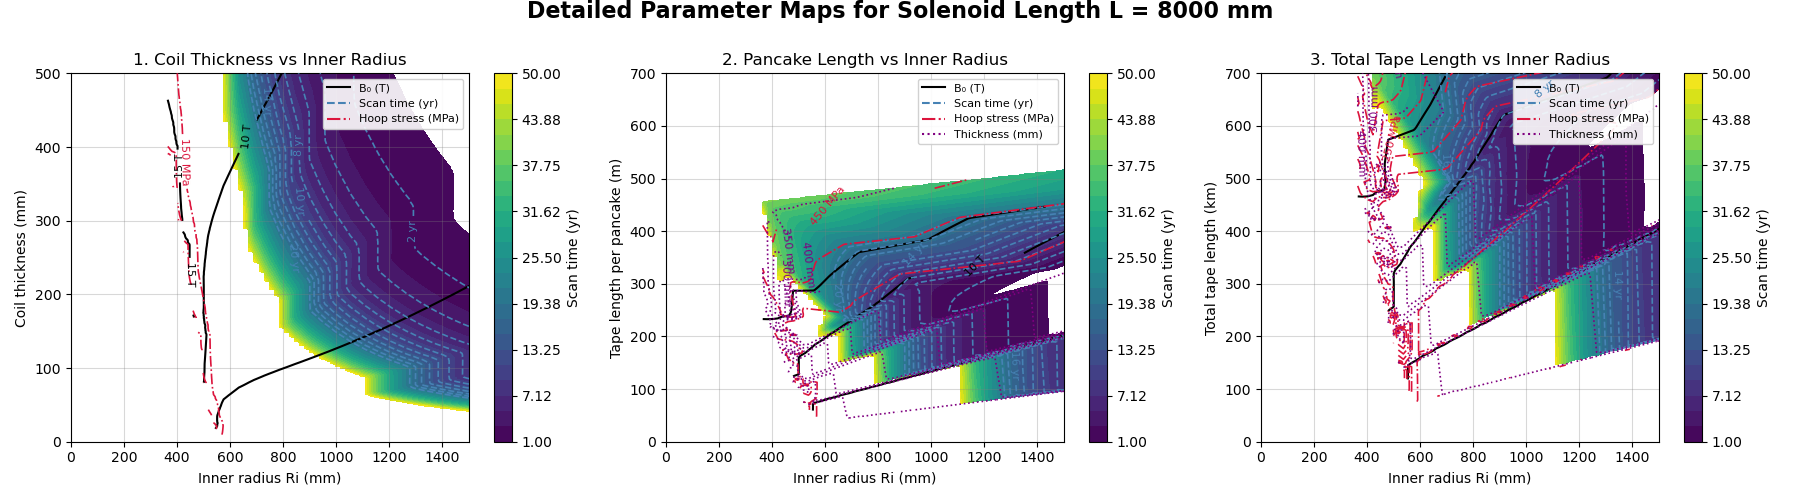

In [15]:
%matplotlib widget
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from scipy.interpolate import griddata
import glob

# -------------------------------------------------------------------------
# 1. LOAD DATA
#    Legacy "sc" column names are remapped per-file, before the concat, so
#    that a mix of old and new CSVs lines up on the same columns instead of
#    producing two half-NaN columns.
# -------------------------------------------------------------------------
_LEGACY_RENAMES = {
    "f_sc": "f_tape_min",
    "length_sc": "length_tape",
    "je_sc": "je_tape",
    "a_sc": "a_tape",
    "rebco_pancake_length": "tape_pancake_length",
    "length_tape_km": "length_tape_km",   # derived col, written by io_grids
}

def _read_grid_csv(path):
    df = pd.read_csv(path)
    hits = {k: v for k, v in _LEGACY_RENAMES.items() if k in df.columns}
    if hits:
        pairs = ", ".join(f"{k}->{v}" for k, v in hits.items())
        print(f"[!] {path}: legacy columns remapped ({pairs})")
        df = df.rename(columns=hits)
    return df

file_list = sorted(glob.glob('thickness_grids_L*.csv'))
if not file_list:
    raise FileNotFoundError("No thickness_grids_L*.csv found in the working directory.")
df_all = pd.concat((_read_grid_csv(f) for f in file_list), ignore_index=True)

# -------------------------------------------------------------------------
# 2. HELPER FUNCTIONS (Interactivity & Regridding)
# -------------------------------------------------------------------------
def setup_grid_annotation(fig, scatters, data_dfs, active_axes):
    annots = []
    for ax in active_axes:
        annot = ax.annotate("", xy=(0, 0), xytext=(15, 15), textcoords="offset points",
                            bbox=dict(boxstyle="round", fc="w", alpha=0.9), fontsize=8, zorder=10)
        annot.set_visible(False)
        annots.append(annot)

    def on_pick(event):
        # Hide all annotations first
        for ann in annots:
            ann.set_visible(False)

        # Find which scatter point was clicked/hovered
        for i, scat in enumerate(scatters):
            if event.artist == scat:
                ind = event.ind[0]
                row = data_dfs[i].iloc[ind]
                x, y = event.artist.get_offsets()[ind]

                text = (f"L={row['solenoid_length_m']:.1f} m\n"
                        f"Ri={row['ri']:.3f} m, Th={row['th']:.3f} m\n"
                        f"B0={row['b0']:.2f} T\n"
                        f"Total tape={row['length_tape_km']:.1f} km\n"
                        f"Pancake={row['pancake_length_m']:.1f} m\n"
                        f"Scan={row['scan']:.1f} yrs")

                annots[i].xy = (x, y)
                annots[i].set_text(text)
                annots[i].set_visible(True)
                fig.canvas.draw_idle()
                break

    fig.canvas.mpl_connect("pick_event", on_pick)


def _regrid(x, y, z, nx=400, ny=400):
    xf, yf, zf = np.asarray(x).flatten(), np.asarray(y).flatten(), np.asarray(z).flatten()
    mask = np.isfinite(xf) & np.isfinite(yf) & np.isfinite(zf)

    if not mask.any():
        xi = np.linspace(np.nanmin(xf) if len(xf) else 0, np.nanmax(xf) if len(xf) else 1, nx)
        yi = np.linspace(np.nanmin(yf) if len(yf) else 0, np.nanmax(yf) if len(yf) else 1, ny)
        xi2d, yi2d = np.meshgrid(xi, yi)
        return xi2d, yi2d, np.full_like(xi2d, np.nan)

    xi = np.linspace(np.nanmin(xf[mask]), np.nanmax(xf[mask]), nx)
    yi = np.linspace(np.nanmin(yf[mask]), np.nanmax(yf[mask]), ny)
    xi2d, yi2d = np.meshgrid(xi, yi)
    zi2d = griddata((xf[mask], yf[mask]), zf[mask], (xi2d, yi2d), method="linear")
    return xi2d, yi2d, zi2d


def draw_contours(ax, x, y, df, plot_type):
    scan_limit = 50.0
    scan_levels = np.linspace(1, scan_limit, 25)
    scan_line_levels = [2, 4, 6, 8, 10, 12, 14, 16, 18, 20]

    field_line_levels = [5, 10, 15, 25, 30, 40, 50, 55, 60]

    th_line_levels = [50, 100, 150, 200, 250, 300, 350, 400]

    # 1. Scan time background map
    xi, yi, zi_scan = _regrid(x, y, df['scan'])
    zi_scan_masked = np.where((zi_scan > 0) & (zi_scan <= scan_limit), zi_scan, np.nan)
    cntr = ax.contourf(xi, yi, zi_scan_masked, levels=scan_levels, cmap='viridis', zorder=1)

    # 2. Magnetic Field (B0)
    _, _, zi_b0 = _regrid(x, y, df['b0'])
    if np.isfinite(zi_b0).any():
        iso_b0 = ax.contour(xi, yi, zi_b0, colors='black', linewidths=1.5, levels=field_line_levels, zorder=3)
        ax.clabel(iso_b0, inline=True, fmt='%.0f T', fontsize=8, colors='black')

    # 3. Scan Time (Lines)
    if np.isfinite(zi_scan).any():
        iso_scan = ax.contour(xi, yi, zi_scan, colors='steelblue', linestyles='dashed', linewidths=1.2, levels=scan_line_levels, zorder=3)
        ax.clabel(iso_scan, inline=True, fmt='%.0f yr', fontsize=8, colors='steelblue')

    # 4. Hoop Stress
    stress_levels = 10 if plot_type == 3 else 3
    _, _, zi_stress = _regrid(x, y, df['stress'])
    if np.isfinite(zi_stress).any():
        iso_stress = ax.contour(xi, yi, zi_stress, colors='crimson', linestyles='dashdot', linewidths=1.2, levels=stress_levels, zorder=3)
        ax.clabel(iso_stress, inline=True, fmt='%.0f MPa', fontsize=8, colors='crimson')

    # 5. Thickness (Only for Graphs 2 and 3)
    if plot_type in [2, 3]:
        _, _, zi_th = _regrid(x, y, df['th'] * 1000)
        if np.isfinite(zi_th).any():
            iso_th = ax.contour(xi, yi, zi_th, colors='purple', linestyles='dotted', linewidths=1.2, levels=th_line_levels, zorder=3)
            ax.clabel(iso_th, inline=True, fmt='%.0f mm', fontsize=8, colors='purple')

    return cntr

# -------------------------------------------------------------------------
# 3. MAIN PLOTTING FUNCTION
# -------------------------------------------------------------------------
def plot_selected_length(target_length_m, df_full):
    # Filter the DataFrame for the selected length
    df_sub = df_full[df_full['solenoid_length_m'] == target_length_m].reset_index(drop=True)

    if df_sub.empty:
        print(f"No data found for L = {target_length_m} m.")
        print(f"Available lengths are: {sorted(df_full['solenoid_length_m'].unique())}")
        return

    # Create the 1x3 figure
    fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(18, 5))
    fig.suptitle(f'Detailed Parameter Maps for Solenoid Length L = {target_length_m*1000:.0f} mm', fontsize=16, fontweight='bold', y=1)

    x_mm = df_sub['ri'] * 1000
    scats = []

    # Legend Elements
    leg1 = [
        Line2D([0], [0], color='black', lw=1.5, label='B₀ (T)'),
        Line2D([0], [0], color='steelblue', lw=1.5, linestyle='--', label='Scan time (yr)'),
        Line2D([0], [0], color='crimson', lw=1.5, linestyle='-.', label='Hoop stress (MPa)')
    ]
    leg23 = leg1 + [Line2D([0], [0], color='purple', lw=1.5, linestyle=':', label='Thickness (mm)')]

    # Graph 1: Coil Thickness
    ax1 = axes[0]
    y1_mm = df_sub['th'] * 1000
    cntr1 = draw_contours(ax1, x_mm, y1_mm, df_sub, plot_type=1)
    fig.colorbar(cntr1, ax=ax1, label='Scan time (yr)')

    ax1.set_xlabel('Inner radius Ri (mm)')
    ax1.set_ylabel('Coil thickness (mm)')
    ax1.set_title('1. Coil Thickness vs Inner Radius')
    ax1.legend(handles=leg1, loc='upper right', framealpha=0.9, fontsize=8).set_zorder(4)
    ax1.grid(True, linestyle='-', color='gray', alpha=0.3, zorder=2)
    scats.append(ax1.scatter(x_mm, y1_mm, color='white', alpha=0.0, picker=5, zorder=5))
    ax1.set_xlim(0, 1500)  # Set x-axis limit to 1500 mm
    ax1.set_ylim(0, 500)   # Set y-axis limit to 500 mm

    # Graph 2: Pancake Length
    ax2 = axes[1]
    y2_m = df_sub['pancake_length_m']
    cntr2 = draw_contours(ax2, x_mm, y2_m, df_sub, plot_type=2)
    fig.colorbar(cntr2, ax=ax2, label='Scan time (yr)')

    ax2.set_xlabel('Inner radius Ri (mm)')
    ax2.set_ylabel('Tape length per pancake (m)')
    ax2.set_title('2. Pancake Length vs Inner Radius')
    ax2.legend(handles=leg23, loc='upper right', framealpha=0.9, fontsize=8).set_zorder(4)
    ax2.grid(True, linestyle='-', color='gray', alpha=0.3, zorder=2)
    scats.append(ax2.scatter(x_mm, y2_m, color='white', alpha=0.0, picker=5, zorder=5))
    ax2.set_xlim(0, 1500)  # Set x-axis limit to 1500 mm
    ax2.set_ylim(0, 700)  # Set y-axis limit to 700 m


    # Graph 3: Total Tape Length
    ax3 = axes[2]
    y3_km = df_sub['length_tape_km']
    cntr3 = draw_contours(ax3, x_mm, y3_km, df_sub, plot_type=3)
    fig.colorbar(cntr3, ax=ax3, label='Scan time (yr)')

    ax3.set_xlabel('Inner radius Ri (mm)')
    ax3.set_ylabel('Total tape length (km)')
    ax3.set_title('3. Total Tape Length vs Inner Radius')
    ax3.legend(handles=leg23, loc='upper right', framealpha=0.9, fontsize=8).set_zorder(4)
    ax3.grid(True, linestyle='-', color='gray', alpha=0.3, zorder=2)
    scats.append(ax3.scatter(x_mm, y3_km, color='white', alpha=0.0, picker=5, zorder=5))
    ax3.set_xlim(0, 1500)  # Set x-axis limit to 1500 mm
    ax3.set_ylim(0, 700)  # Set y-axis limit to 700 km

    # Connect interactivity and adjust layout
    setup_grid_annotation(fig, scats, [df_sub, df_sub, df_sub], axes)
    fig.tight_layout()
    plt.show()

# -------------------------------------------------------------------------
# 4. EXECUTE PLOT
# Change the length below to map a different target length (e.g. 5.0, 6.0)
# -------------------------------------------------------------------------
selected_length = 8.0
plot_selected_length(selected_length, df_all)

# Parameter Maps — Contour Grids across Solenoid Lengths

Loads every `thickness_grids_L*.csv` in the working directory and draws three
2×5 figures, one panel per value of `solenoid_length_m` (first ten only; any
further lengths are silently dropped by the `if i >= 10: break` guard).

All panels share `Ri` (mm) on the x-axis and a filled scan-time background,
differing only in the y-quantity: **Fig. 1** coil thickness (mm), **Fig. 2**
tape length per pancake (m), **Fig. 3** total tape length (km). Iso-lines:
**B₀** (black), **scan time** (blue, dashed), **hoop stress** (crimson,
dash-dot), plus **thickness** (purple, dotted) on Figs. 2 and 3. Grid nodes are
drawn invisibly as pick targets — click one for a tooltip with its full
parameter set.

Values are interpolated onto a 400×400 mesh with `griddata`; blank regions are
outside the convex hull of that panel's data, not physically excluded. Each
panel regrids over its own x/y extent, so meshes are not aligned between
panels. Figures 2 and 3 use `sharey=True` with explicit limits (0–3000 m and
0–1500 km); Figure 1's axes are left to autoscale, so its y-range varies panel
to panel.

> The scan-time fill is clipped to 1–20 yr on a fixed 25-level scale, so the
> colour mapping is comparable across every panel and figure — designs outside
> that window show as blank background.
>
> B₀ and stress iso-lines use automatic level selection, so their values differ
> between panels; pin them to explicit level lists before comparing panels.
>
> No `*_sc` legacy column remapping is performed in this version — all input
> files must already use `ri`, `th`, `b0`, `stress`, `scan`,
> `pancake_length_m`, `length_tape_km`, `solenoid_length_m`.
>
> Tooltips need `%matplotlib widget` and a live kernel.

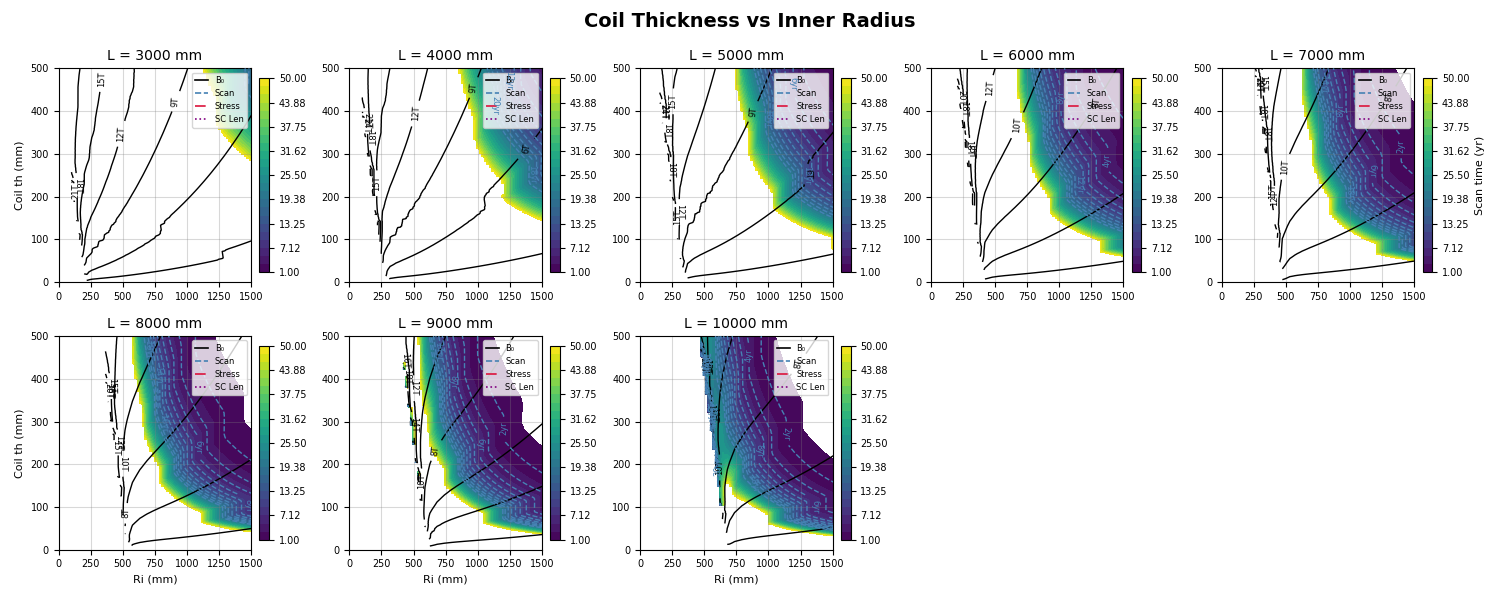

In [16]:
%matplotlib widget
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from scipy.interpolate import griddata
import glob

# -------------------------------------------------------------------------
# 1. LOAD DATA
# -------------------------------------------------------------------------
file_list = glob.glob('thickness_grids_L*.csv')
df_all = pd.concat((pd.read_csv(f) for f in file_list), ignore_index=True)

# -------------------------------------------------------------------------
# 2. HELPER FUNCTIONS
# -------------------------------------------------------------------------
def setup_grid_annotation(fig, scatters, data_dfs, active_axes):
    annots = []
    for ax in active_axes:
        annot = ax.annotate("", xy=(0, 0), xytext=(10, 10), textcoords="offset points",
                            bbox=dict(boxstyle="round", fc="w", alpha=0.9), fontsize=7, zorder=10)
        annot.set_visible(False)
        annots.append(annot)

    def on_pick(event):
        for ann in annots:
            ann.set_visible(False)
            
        for i, scat in enumerate(scatters):
            if event.artist == scat:
                ind = event.ind[0]
                row = data_dfs[i].iloc[ind]
                x, y = event.artist.get_offsets()[ind]
                
                text = (f"L={row['solenoid_length_m']:.1f} m\n"
                        f"Ri={row['ri']:.3f} m, Th={row['th']:.3f} m\n"
                        f"B0={row['b0']:.2f} T\n"
                        f"Total SC={row['length_tape_km']:.1f} km\n"
                        f"Pancake={row['pancake_length_m']:.1f} m\n"
                        f"Scan={row['scan']:.1f} yrs")
                
                annots[i].xy = (x, y)
                annots[i].set_text(text)
                annots[i].set_visible(True)
                fig.canvas.draw_idle()
                break

    fig.canvas.mpl_connect("pick_event", on_pick)


def _regrid(x, y, z, nx=400, ny=400):
    xf, yf, zf = np.asarray(x).flatten(), np.asarray(y).flatten(), np.asarray(z).flatten()
    mask = np.isfinite(xf) & np.isfinite(yf) & np.isfinite(zf)
    
    if not mask.any():
        xi = np.linspace(np.nanmin(xf) if len(xf) else 0, np.nanmax(xf) if len(xf) else 1, nx)
        yi = np.linspace(np.nanmin(yf) if len(yf) else 0, np.nanmax(yf) if len(yf) else 1, ny)
        xi2d, yi2d = np.meshgrid(xi, yi)
        return xi2d, yi2d, np.full_like(xi2d, np.nan)
        
    xi = np.linspace(np.nanmin(xf[mask]), np.nanmax(xf[mask]), nx)
    yi = np.linspace(np.nanmin(yf[mask]), np.nanmax(yf[mask]), ny)
    xi2d, yi2d = np.meshgrid(xi, yi)
    zi2d = griddata((xf[mask], yf[mask]), zf[mask], (xi2d, yi2d), method="linear")
    return xi2d, yi2d, zi2d


def draw_contours_small(ax, x, y, df):
    scan_limit = 50.0
    scan_levels = np.linspace(1, scan_limit, 25)
    scan_line_levels = [2, 4, 6, 8, 10, 12, 14, 16, 18, 20] 

    xi, yi, zi_scan = _regrid(x, y, df['scan'])
    zi_scan_masked = np.where((zi_scan > 0) & (zi_scan <= scan_limit), zi_scan, np.nan)
    cntr = ax.contourf(xi, yi, zi_scan_masked, levels=scan_levels, cmap='viridis', zorder=1)
    
    _, _, zi_b0 = _regrid(x, y, df['b0'])
    if np.isfinite(zi_b0).any():
        iso_b0 = ax.contour(xi, yi, zi_b0, colors='black', linewidths=1.0, levels=10, zorder=3)
        ax.clabel(iso_b0, inline=True, fmt='%.0fT', fontsize=6, colors='black')

    if np.isfinite(zi_scan).any():
        iso_scan = ax.contour(xi, yi, zi_scan, colors='steelblue', linestyles='dashed', linewidths=1.0, levels=scan_line_levels, zorder=3)
        ax.clabel(iso_scan, inline=True, fmt='%.0fyr', fontsize=6, colors='steelblue')

    # _, _, zi_stress = _regrid(x, y, df['stress'])
    # if np.isfinite(zi_stress).any():
    #     iso_stress = ax.contour(xi, yi, zi_stress, colors='crimson', linestyles='dashdot', linewidths=1.0, levels=3, zorder=3)
    #     ax.clabel(iso_stress, inline=True, fmt='%.0fMPa', fontsize=6, colors='crimson')
            
    return cntr


def draw_contours_small_2_3(ax, x, y, df, plot_type):
    scan_limit = 50.0
    scan_levels = np.linspace(1, scan_limit, 25)
    scan_line_levels = [2, 4, 6, 8, 10, 12, 14, 16, 18, 20, 50] 

    field_line_levels = [5, 10 ,15, 25, 30, 40, 50, 55, 60] 

    th_line_levels = [50, 100, 150, 200, 250, 300, 350, 400]

    xi, yi, zi_scan = _regrid(x, y, df['scan'])
    zi_scan_masked = np.where((zi_scan > 0) & (zi_scan <= scan_limit), zi_scan, np.nan)
    cntr = ax.contourf(xi, yi, zi_scan_masked, levels=scan_levels, cmap='viridis', zorder=1)
    
    # B0
    _, _, zi_b0 = _regrid(x, y, df['b0'])
    if np.isfinite(zi_b0).any():
        iso_b0 = ax.contour(xi, yi, zi_b0, colors='black', linewidths=1.0, levels=field_line_levels, zorder=3)
        ax.clabel(iso_b0, inline=True, fmt='%.0fT', fontsize=6, colors='black')

    # Scan Time
    if np.isfinite(zi_scan).any():
        iso_scan = ax.contour(xi, yi, zi_scan, colors='steelblue', linestyles='dashed', linewidths=1.0, levels=scan_line_levels, zorder=3)
        ax.clabel(iso_scan, inline=True, fmt='%.0fyr', fontsize=6, colors='steelblue')

    # # Hoop Stress (Graph 3 often needs more levels to show detail)
    # stress_levels = 10 if plot_type == 3 else 3
    # _, _, zi_stress = _regrid(x, y, df['stress'])
    # if np.isfinite(zi_stress).any():
    #     iso_stress = ax.contour(xi, yi, zi_stress, colors='crimson', linestyles='dashdot', linewidths=1.0, levels=stress_levels, zorder=3)
    #     ax.clabel(iso_stress, inline=True, fmt='%.0fMPa', fontsize=6, colors='crimson')

    # Thickness Lines (Purple dotted)
    _, _, zi_th = _regrid(x, y, df['th'] * 1000)
    if np.isfinite(zi_th).any():
        iso_th = ax.contour(xi, yi, zi_th, colors='purple', linestyles='dotted', linewidths=1.0, levels=th_line_levels, zorder=3)
        ax.clabel(iso_th, inline=True, fmt='%.0fmm', fontsize=6, colors='purple')
            
    return cntr

# Legend for Graphs 2 and 3
leg23_elements = [
    Line2D([0], [0], color='black', lw=1.2, label='B₀'),
    Line2D([0], [0], color='steelblue', lw=1.2, linestyle='--', label='Scan'),
    Line2D([0], [0], color='crimson', lw=1.2, linestyle='-.', label='Stress'),
    Line2D([0], [0], color='purple', lw=1.2, linestyle=':', label='Thickness') 
]

unique_lengths = sorted(df_all['solenoid_length_m'].unique())



# -------------------------------------------------------------------------
# 3. SET UP GRID AND PLOT
# -------------------------------------------------------------------------
unique_lengths = sorted(df_all['solenoid_length_m'].unique())

# Smaller figure size
fig, axes = plt.subplots(nrows=2, ncols=5, figsize=(15, 6), squeeze=False)
fig.suptitle('Coil Thickness vs Inner Radius', fontsize=14, fontweight='bold')

axes_flat = axes.flatten()
scats = []
dfs = []
active_axes = []

# Compact legend elements
leg1_elements = [
    Line2D([0], [0], color='black', lw=1.2, label='B₀'),
    Line2D([0], [0], color='steelblue', lw=1.2, linestyle='--', label='Scan'),
    Line2D([0], [0], color='crimson', lw=1.2, linestyle='-.', label='Stress'),
    Line2D([0], [0], color='purple', lw=1.2, linestyle=':', label='SC Len') 
]

for i, L in enumerate(unique_lengths):
    if i >= 10:
        break
        
    df_sub = df_all[df_all['solenoid_length_m'] == L].reset_index(drop=True)
    ax = axes_flat[i]
    
    x_mm = df_sub['ri'] * 1000
    y1_mm = df_sub['th'] * 1000
    
    cntr = draw_contours_small(ax, x_mm, y1_mm, df_sub)
    
    # Add a thin colorbar with smaller font
    cbar = fig.colorbar(cntr, ax=ax, fraction=0.046, pad=0.04)
    cbar.ax.tick_params(labelsize=7)
    if i % 5 == 4: # Only label the colorbars on the far right to save space
        cbar.set_label('Scan time (yr)', size=8)
    
    if i >= 5: # Only label x-axis on bottom row
        ax.set_xlabel('Ri (mm)', fontsize=8)
    if i % 5 == 0:
        ax.set_ylabel('Coil th (mm)', fontsize=8)
        
    ax.tick_params(axis='both', which='major', labelsize=7)
    ax.set_title(f'L = {L*1000:.0f} mm', fontsize=10)
    
    ax.legend(handles=leg1_elements, loc='upper right', framealpha=0.8, fontsize=6, handlelength=1.5).set_zorder(4)
    ax.grid(True, linestyle='-', color='gray', alpha=0.3, zorder=2)
    
    #scat = ax.scatter(x_mm, y1_mm, color='white', alpha=0.0, picker=5, zorder=5)

    ax.set_xlim(0, 1500)    
    ax.set_ylim(0, 500)     
    
    #scats.append(scat)
    dfs.append(df_sub)
    active_axes.append(ax)

# Hide any blank subplots
for j in range(len(active_axes), len(axes_flat)):
    axes_flat[j].set_visible(False)

setup_grid_annotation(fig, scats, dfs, active_axes)


fig.tight_layout()
plt.show()



# # =========================================================================
# # FIGURE 2: PANCAKE LENGTH VS INNER RADIUS (Shared Y-Axis)
# # =========================================================================
# # Find global min and max for pancake length to set consistent limits
# y2_min, y2_max = df_all['pancake_length_m'].min(), 3000

# # Add sharey=True here
# fig2, axes2 = plt.subplots(nrows=2, ncols=5, figsize=(15, 6), squeeze=False, sharey=True)
# fig2.suptitle('2. Pancake Length vs Inner Radius', fontsize=14, fontweight='bold')

# axes2_flat = axes2.flatten()
# scats2, dfs2, active_axes2 = [], [], []

# for i, L in enumerate(unique_lengths):
#     if i >= 10: break
#     df_sub = df_all[df_all['solenoid_length_m'] == L].reset_index(drop=True)
#     ax = axes2_flat[i]
#     x_mm = df_sub['ri'] * 1000
#     y2_m = df_sub['pancake_length_m']
    
#     cntr = draw_contours_small_2_3(ax, x_mm, y2_m, df_sub, plot_type=2)
    
#     cbar = fig2.colorbar(cntr, ax=ax, fraction=0.046, pad=0.04)
#     cbar.ax.tick_params(labelsize=7)
#     if i % 5 == 4: cbar.set_label('Scan time (yr)', size=8)
    
#     if i >= 5: ax.set_xlabel('Ri (mm)', fontsize=8)
#     if i % 5 == 0: ax.set_ylabel('Pancake len (m)', fontsize=8)
        
#     ax.tick_params(axis='both', which='major', labelsize=7)
#     ax.set_title(f'L = {L*1000:.0f} mm', fontsize=10)
    
#     # Set the shared limits explicitly
#     ax.set_ylim(y2_min - y2_pad, y2_max + y2_pad)
    
#     ax.legend(handles=leg23_elements, loc='upper right', framealpha=0.8, fontsize=6, handlelength=1.5).set_zorder(4)
#     ax.grid(True, linestyle='-', color='gray', alpha=0.3, zorder=2)
    
#     scat = ax.scatter(x_mm, y2_m, color='white', alpha=0.0, picker=5, zorder=5)
#     scats2.append(scat); dfs2.append(df_sub); active_axes2.append(ax)

# for j in range(len(active_axes2), len(axes2_flat)): axes2_flat[j].set_visible(False)
# setup_grid_annotation(fig2, scats2, dfs2, active_axes2)
# fig2.tight_layout()


# # =========================================================================
# # FIGURE 3: TOTAL REBCO LENGTH VS INNER RADIUS (Shared Y-Axis)
# # =========================================================================
# # Find global min and max for total length
# y3_min, y3_max = df_all['length_tape_km'].min(), 1500
# y3_pad = 0

# # Add sharey=True here
# fig3, axes3 = plt.subplots(nrows=2, ncols=5, figsize=(15, 6), squeeze=False, sharey=True)
# fig3.suptitle('3. Total REBCO Length vs Inner Radius', fontsize=14, fontweight='bold')

# axes3_flat = axes3.flatten()
# scats3, dfs3, active_axes3 = [], [], []

# for i, L in enumerate(unique_lengths):
#     if i >= 10: break
#     df_sub = df_all[df_all['solenoid_length_m'] == L].reset_index(drop=True)
#     ax = axes3_flat[i]
#     x_mm = df_sub['ri'] * 1000
#     y3_km = df_sub['length_tape_km']
    
#     cntr = draw_contours_small_2_3(ax, x_mm, y3_km, df_sub, plot_type=3)
    
#     cbar = fig3.colorbar(cntr, ax=ax, fraction=0.046, pad=0.04)
#     cbar.ax.tick_params(labelsize=7)
#     if i % 5 == 4: cbar.set_label('Scan time (yr)', size=8)
    
#     if i >= 5: ax.set_xlabel('Ri (mm)', fontsize=8)
#     if i % 5 == 0: ax.set_ylabel('Total SC len (km)', fontsize=8)
        
#     ax.tick_params(axis='both', which='major', labelsize=7)
#     ax.set_title(f'L = {L*1000:.0f} mm', fontsize=10)
    
#     # Set the shared limits explicitly
#     ax.set_ylim(y3_min - y3_pad, y3_max + y3_pad)
    
#     ax.legend(handles=leg23_elements, loc='upper right', framealpha=0.8, fontsize=6, handlelength=1.5).set_zorder(4)
#     ax.grid(True, linestyle='-', color='gray', alpha=0.3, zorder=2)
    
#     scat = ax.scatter(x_mm, y3_km, color='white', alpha=0.0, picker=5, zorder=5)
#     scats3.append(scat); dfs3.append(df_sub); active_axes3.append(ax)

# for j in range(len(active_axes3), len(axes3_flat)): axes3_flat[j].set_visible(False)
# setup_grid_annotation(fig3, scats3, dfs3, active_axes3)
# fig3.tight_layout()

# plt.show()

# Global Scatter Plots — Scan Time and Field/Volume Positioning

Concatenates every `thickness_grids_L*.csv` in the working directory into one
frame and produces three standalone figures over the whole design database,
with no per-length faceting.

## Filtering

A single window, `1.0 <= scan <= 10.0` yr, is applied once to produce
`df_filtered`; all three figures share it. Figures 1 and 2 set their y-limits to
that same window, so the filter and the visible range coincide and nothing is
clipped. Figure 3 reuses the bounds as `vmin`/`vmax` on the scan-time colour
scale, so its colours are directly comparable to the y-positions in Figures 1
and 2.

## Figures

**1 and 2** plot scan time against total tape length (km) and against tape
length per pancake (m), coloured by `solenoid_length_m`. Both autoscale the
upper x-limit from the data.

**3** plots `b0` against `v` for the design database, coloured by scan time, and
overlays five reference families: user-defined operating points (stars,
coloured by cavity Q), built axion solenoids (orange diamonds), built REBCO
high-field solenoids (green triangles), designed/future REBCO solenoids (red
inverted triangles), MRI solenoids (blue squares) and collider detector
solenoids (purple hexagons). Each overlay point is labelled through
`label_layout`, keyed by name, giving an offset in points plus horizontal and
vertical alignment; unlisted names fall back to a per-family default. Repeated
`label=` arguments are collapsed by the `by_label` dict before the legend is
drawn.

Clicking any database point in any figure opens a tooltip with its full
parameter set. Overlay points are not pickable.

> Figure 3's x-axis is linear and hard-limited to 0–50 m³ while the plotted
> volumes span about six orders of magnitude. Every non-collider reference point
> renders against the y-axis, and coincident points are separated only by their
> label offsets. Any database design above 50 m³ is off-screen.
>
> Volume conventions differ between the reference blocks; the collider, axion
> and MRI figures are bore volumes, while the built-REBCO figures appear to be
> field-homogeneity volumes. Confirm before reading across families.
>
> `custom_points` tuples carry two fields that are unpacked and discarded
> (positions 4 and 5, apparently noise floor and scan time); only `b0`, `v`,
> `Q` and the name reach the plot.
>
> If the input files have no `v` column, Figure 3 silently plots the entire
> database at v = 0 rather than raising.
>
> Tooltips need `%matplotlib widget` and a live kernel. This cell also assumes
> `glob` and `pandas` are already imported.

loaded 8 files, 177600 rows
35735 rows with 1 <= scan <= 10 yrs
K = 8.48284e+08   spread max/min = 1.0000   -> analytic isolines
cells near each level (absolute tolerance):
  1 yr  +/-0.1 : 3429
  2 yr  +/-0.1 : 1631
  4 yr  +/-0.1 : 778
  6 yr  +/-0.1 : 451
  8 yr  +/-0.1 : 318
  10 yr  +/-0.1 : 267


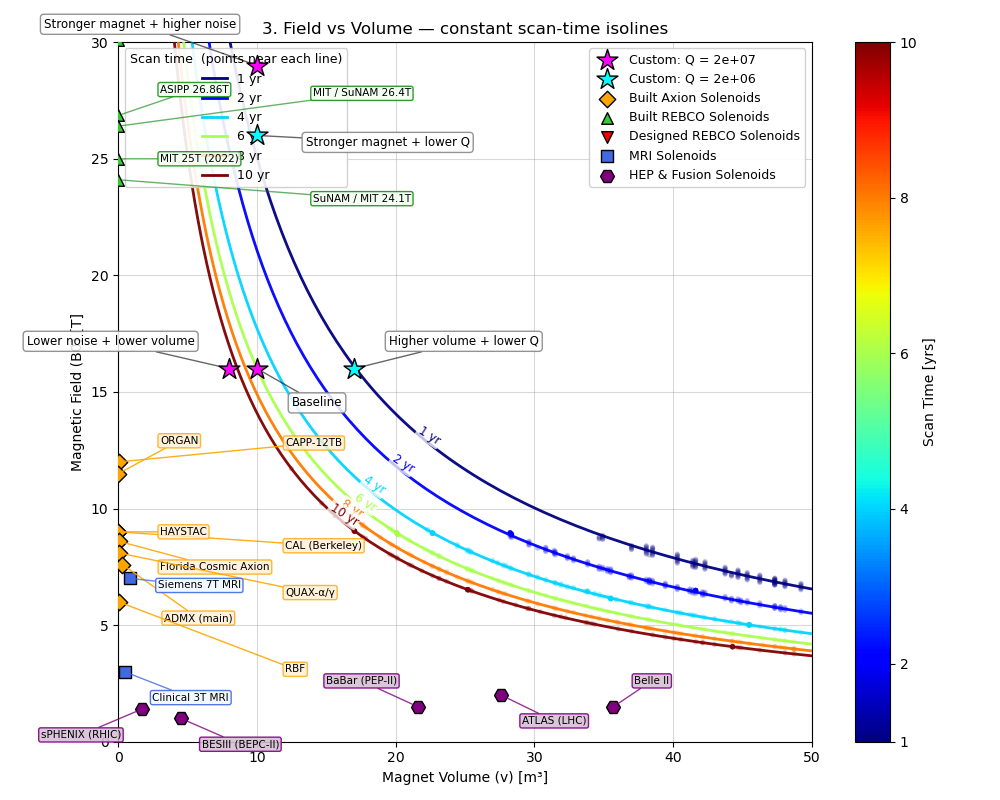

In [17]:
# -------------------------------------------------------------------------
# GLOBAL SCATTER PLOTS (Figs 1, 2, 3)
#   Fig 3: constant-scan-time ISOLINES, with the solved cells that lie near
#          each level drawn as a faint jet-coloured underlay.
#   t = K / (B0^4 * V^(10/3))  ->  B0(V) = (K/t)^(1/4) * V^(-5/6)
#   K is calibrated from the data; if the data does not obey the closed
#   form the code falls back to tricontour on the raw cloud.
# -------------------------------------------------------------------------
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.lines import Line2D
import numpy as np
import glob
import pandas as pd

# -------------------------------------------------------------------------
# 0. USER CONTROLS
# -------------------------------------------------------------------------
min_scan_years = 1
max_scan_years = 10

CMAP_NAME         = 'jet'
SCAN_LEVELS       = [1, 2, 4, 6, 8, 10]   # isolines to draw [yrs]
LEVEL_TOL         = 0.1               # +/- window around each level [yrs]
USE_REL_TOL       = False              # True -> window is +/- REL_TOL * level
REL_TOL           = 0.05
SHOW_LEVEL_POINTS = True               # solved cells near each isoline
LEVEL_PT_MODE     = 'gradient'         # 'gradient' (by own scan) | 'flat' (by level)
LEVEL_PT_SIZE     = 14                 # faint underlay, as in the landscape plot
LEVEL_PT_ALPHA    = 0.25
SHOW_ALL_POINTS   = False              # faint underlay of every solved cell
SHOW_BANDS        = False              # shade between consecutive isolines
LABEL_ISOLINES    = True
ISO_FRAC          = 0.55               # 0..1 : where along the visible arc to label
LOG_X             = False              # log volume axis -> isolines straighten

EXP_B, EXP_V = 4.0, 10.0 / 3.0         # exponents in t = K / (B0^EXP_B * V^EXP_V)

# Axis limits for Graph 1 & 2
g1_xlim = (0, None)
g1_ylim = (min_scan_years, max_scan_years)
g2_xlim = (0, None)
g2_ylim = (min_scan_years, max_scan_years)

# Axis limits for Graph 3
g3_xlim = (0, 50)
g3_ylim = (0, 30)

# -------------------------------------------------------------------------
# 1. LOAD DATA
# -------------------------------------------------------------------------
file_list = glob.glob('thickness_grids_L*.csv')
if file_list:
    df_all = pd.concat((pd.read_csv(f) for f in file_list), ignore_index=True)
    print(f"loaded {len(file_list)} files, {len(df_all)} rows")
else:
    print("WARNING: no 'thickness_grids_L*.csv' found -> empty database")
    df_all = pd.DataFrame(columns=['ri', 'th', 'b0', 'v', 'scan',
                                   'length_tape_km', 'pancake_length_m',
                                   'solenoid_length_m'])

if 'v' not in df_all.columns:
    raise KeyError("the CSVs have no 'v' column - the volume axis and the "
                   "scan-time isolines both need it")

df_filtered = df_all[(df_all['scan'] >= min_scan_years) &
                     (df_all['scan'] <= max_scan_years)].reset_index(drop=True)
print(f"{len(df_filtered)} rows with {min_scan_years} <= scan <= {max_scan_years} yrs")


# -------------------------------------------------------------------------
# 1b. INTERACTIVE PICK ANNOTATION (several scatter artists)
# -------------------------------------------------------------------------
def _f(row, key, fmt=".3g"):
    """Format one field of a row, tolerating missing columns."""
    val = row.get(key, np.nan)
    try:
        if val is None or (isinstance(val, float) and not np.isfinite(val)):
            return "—"
        return format(float(val), fmt)
    except (TypeError, ValueError):
        return str(val)


def setup_pick_annotation(fig, ax, pairs):
    """pairs = list of (scatter_artist, dataframe) with matching row order."""
    annot = ax.annotate("", xy=(0, 0), xytext=(15, 15), textcoords="offset points",
                        bbox=dict(boxstyle="round", fc="w", alpha=0.92),
                        fontsize=8, zorder=20)
    annot.set_visible(False)
    lookup = {id(artist): sub for artist, sub in pairs}

    def on_pick(event):
        sub = lookup.get(id(event.artist))
        if sub is None:
            return
        ind = event.ind[0]
        row = sub.iloc[ind]
        x, y = event.artist.get_offsets()[ind]
        annot.xy = (x, y)
        annot.set_text(
            f"L={_f(row, 'solenoid_length_m', '.1f')} m\n"
            f"Ri={_f(row, 'ri', '.3f')} m, Th={_f(row, 'th', '.3f')} m\n"
            f"B0={_f(row, 'b0', '.2f')} T\n"
            f"Total SC={_f(row, 'length_tape_km', '.1f')} km\n"
            f"Pancake SC={_f(row, 'pancake_length_m', '.1f')} m\n"
            f"Scan={_f(row, 'scan', '.2f')} yrs\n"
            f"Vol={_f(row, 'v', '.3g')} m3")
        annot.set_visible(True)
        fig.canvas.draw_idle()

    fig.canvas.mpl_connect("pick_event", on_pick)


# -------------------------------------------------------------------------
# 1c. ISOLINE HELPERS
# -------------------------------------------------------------------------
def scan_isoline(t, K, vlo, vhi, n=600):
    """B0(V) along a constant-scan-time contour."""
    v = np.geomspace(max(vlo, 1e-6), vhi, n)
    return v, (K / (t * v ** EXP_V)) ** (1.0 / EXP_B)


def label_on_line(ax, x, y, text, color, frac=0.5, fontsize=8.5):
    """Put a rotated label on the visible part of a curve."""
    x0, x1 = ax.get_xlim()
    y0, y1 = ax.get_ylim()
    ok = (x >= x0) & (x <= x1) & (y >= y0) & (y <= y1)
    if not ok.any():
        return
    xs, ys = x[ok], y[ok]
    i = int(np.clip(round(frac * (len(xs) - 1)), 0, len(xs) - 1))
    a, b = max(i - 1, 0), min(i + 1, len(xs) - 1)
    p1 = ax.transData.transform((xs[a], ys[a]))
    p2 = ax.transData.transform((xs[b], ys[b]))
    ang = np.degrees(np.arctan2(p2[1] - p1[1], p2[0] - p1[0]))
    ax.text(xs[i], ys[i], text, color=color, fontsize=fontsize,
            rotation=ang, rotation_mode='anchor', ha='center', va='bottom',
            zorder=9,
            bbox=dict(boxstyle="round,pad=0.15", fc='white', ec='none',
                      alpha=0.75))


# # -------------------------------------------------------------------------
# # 1. Scan time vs REBCO total length
# # -------------------------------------------------------------------------
# fig1, ax1 = plt.subplots(figsize=(8, 6))
# scat1 = ax1.scatter(df_filtered['length_tape_km'], df_filtered['scan'],
#                     c=df_filtered['solenoid_length_m'], cmap=CMAP_NAME,
#                     alpha=0.7, picker=5)
# fig1.colorbar(scat1, ax=ax1, label='Solenoid Length [m]')
# ax1.set_xlabel('REBCO total length [km]')
# ax1.set_ylabel('Scan Time [yrs]')
# ax1.set_xlim(g1_xlim)
# ax1.set_ylim(g1_ylim)
# ax1.set_title('1. Scan Time vs Total REBCO Length (1 <= Scan <= 10 yrs)')
# ax1.grid(True, linestyle='-', color='gray', alpha=0.3)
# setup_pick_annotation(fig1, ax1, [(scat1, df_filtered)])
# fig1.tight_layout()

# # -------------------------------------------------------------------------
# # 2. Scan time vs REBCO length per pancake
# # -------------------------------------------------------------------------
# fig2, ax2 = plt.subplots(figsize=(8, 6))
# scat2 = ax2.scatter(df_filtered['pancake_length_m'], df_filtered['scan'],
#                     c=df_filtered['solenoid_length_m'], cmap=CMAP_NAME,
#                     alpha=0.7, picker=5)
# fig2.colorbar(scat2, ax=ax2, label='Solenoid Length [m]')
# ax2.set_xlabel('REBCO length per pancake [m]')
# ax2.set_ylabel('Scan Time [yrs]')
# ax2.set_xlim(g2_xlim)
# ax2.set_ylim(g2_ylim)
# ax2.set_title('2. Scan Time vs Pancake Length (1 <= Scan <= 10 yrs)')
# ax2.grid(True, linestyle='-', color='gray', alpha=0.3)
# setup_pick_annotation(fig2, ax2, [(scat2, df_filtered)])
# fig2.tight_layout()

# -------------------------------------------------------------------------
# 3. Field vs Volume + scan-time isolines + nearby cells + magnet database
# -------------------------------------------------------------------------
fig3, ax3 = plt.subplots(figsize=(10, 8))

norm = mpl.colors.Normalize(vmin=min_scan_years, vmax=max_scan_years)
cmap = plt.get_cmap(CMAP_NAME)

# limits must be final BEFORE the isolines are labelled (rotation needs them)
if LOG_X:
    ax3.set_xscale('log')
ax3.set_xlim(g3_xlim)
ax3.set_ylim(g3_ylim)

pick_pairs = []

# --- calibrate K from the data -------------------------------------------
mask = (df_all['scan'] > 0) & (df_all['b0'] > 0) & (df_all['v'] > 0)
K_all = (df_all.loc[mask, 'scan'] *
         df_all.loc[mask, 'b0'] ** EXP_B *
         df_all.loc[mask, 'v'] ** EXP_V)
if len(K_all):
    K = float(np.median(K_all))
    spread = float(K_all.max() / K_all.min())
    analytic = np.isfinite(spread) and spread < 1.01
    print(f"K = {K:.6g}   spread max/min = {spread:.4f}   "
          f"-> {'analytic isolines' if analytic else 'FALLBACK to tricontour'}")
else:
    K, analytic = np.nan, False
    print("no usable rows for K -> no isolines")

# --- optional faint underlay of every solved cell ------------------------
if SHOW_ALL_POINTS and len(df_filtered):
    sc_bg = ax3.scatter(df_filtered['v'], df_filtered['b0'],
                        c=df_filtered['scan'], cmap=cmap, norm=norm,
                        alpha=0.15, s=8, linewidths=0, picker=5, zorder=2)
    pick_pairs.append((sc_bg, df_filtered))

# --- the solved cells that sit near each level (faint, jet-coloured) -----
if SHOW_LEVEL_POINTS and len(df_all):
    print(f"cells near each level ({'relative' if USE_REL_TOL else 'absolute'} "
          f"tolerance):")
    for t in SCAN_LEVELS:
        tol = REL_TOL * t if USE_REL_TOL else LEVEL_TOL
        sub = df_all[(df_all['scan'] >= t - tol) &
                     (df_all['scan'] <= t + tol)].reset_index(drop=True)
        print(f"  {t:g} yr  +/-{tol:.3g} : {len(sub)}")
        if not len(sub):
            continue
        if LEVEL_PT_MODE == 'gradient':
            sc = ax3.scatter(sub['v'], sub['b0'],
                             c=sub['scan'], cmap=cmap, norm=norm,
                             alpha=LEVEL_PT_ALPHA, s=LEVEL_PT_SIZE,
                             linewidths=0, picker=5, zorder=2)
        else:
            sc = ax3.scatter(sub['v'], sub['b0'],
                             color=cmap(norm(t)),
                             alpha=LEVEL_PT_ALPHA, s=LEVEL_PT_SIZE,
                             linewidths=0, picker=5, zorder=2)
        pick_pairs.append((sc, sub))

# --- the isolines ---------------------------------------------------------
iso_handles = []
if analytic:
    vlo = g3_xlim[0] if (g3_xlim[0] and g3_xlim[0] > 0) else 1e-3
    vhi = g3_xlim[1] if g3_xlim[1] else float(df_all['v'].max())

    curves = {t: scan_isoline(t, K, vlo, vhi) for t in SCAN_LEVELS}

    if SHOW_BANDS:
        for t_lo, t_hi in zip(SCAN_LEVELS[:-1], SCAN_LEVELS[1:]):
            v, b_hi = curves[t_lo]          # faster scan -> higher B0
            _, b_lo = curves[t_hi]
            ax3.fill_between(v, b_lo, b_hi,
                             color=cmap(norm(0.5 * (t_lo + t_hi))),
                             alpha=0.10, lw=0, zorder=1)

    for t in SCAN_LEVELS:
        col = cmap(norm(t))
        v, b = curves[t]
        ax3.plot(v, b, color=col, lw=2.0, alpha=0.95, zorder=4)
        if LABEL_ISOLINES:
            label_on_line(ax3, v, b, f'{t:g} yr', col, frac=ISO_FRAC)
        iso_handles.append(Line2D([], [], color=col, lw=2.0, label=f'{t:g} yr'))
else:
    if len(K_all):
        from matplotlib.tri import Triangulation
        d = df_all[mask]
        tri = Triangulation(d['v'].to_numpy(), d['b0'].to_numpy())
        cs = ax3.tricontour(tri, d['scan'].to_numpy(), levels=SCAN_LEVELS,
                            cmap=cmap, norm=norm, linewidths=2.0, zorder=4)
        ax3.clabel(cs, fmt='%g yr', fontsize=8.5, inline=True)
        iso_handles = [Line2D([], [], color=cmap(norm(t)), lw=2.0, label=f'{t:g} yr')
                       for t in SCAN_LEVELS]

# --- colorbar keeps the gradient even with no continuous scatter ---------
sm = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])
cb = fig3.colorbar(sm, ax=ax3, label='Scan Time [yrs]')
cb.set_ticks(SCAN_LEVELS)

# -------------------------------------------------------------------------
# 3b. DEFINITIONS
# -------------------------------------------------------------------------
custom_points = [
    (16, 10, 20e6, -20, 6.2,  'Baseline'),
    (29, 10, 20e6, -5,  3.2,  'Stronger magnet + higher noise'),
    (16,  8, 20e6, -25, 7.3,  'Lower noise + lower volume'),
    (16, 17,  2e6, -20, 10.6, 'Higher volume + lower Q'),
    (26, 10,  2e6, -20, 8.9,  'Stronger magnet + lower Q')
]
q_colors = {20e6: 'magenta', 2e6: 'cyan'}

axion_magnets = [
    (12.0, 0.021, 'CAPP-12TB'),
    (11.5, 0.000048, 'ORGAN'),
    (9.0,  0.007, 'CAL (Berkeley)'),
    (9.0,  0.002, 'HAYSTAC'),
    (8.6,  0.008, 'Florida Cosmic Axion'),
    (8.1,  0.009, 'QUAX-α/γ'),
    (7.6,  0.283, 'ADMX (main)'),
    (6.0,  0.011, 'RBF')
]

rebco_built = [
    (45.5, 0.000008, 'LBC3 (NHMFL) 45.5T'),
    (44.0, 0.000008, 'LBC4-5 (NHMFL) 44T'),
    (43.0, 0.000008, 'LBC6 (NHMFL) 43T'),
    (42.5, 0.000008, 'LBC2 (NHMFL) 42.5T'),
    (40.2, 0.000008, 'LBC1 (NHMFL) 40.2T'),
    (32.5, 0.000240, 'NOUGAT 32.5T'),
    (32.4, 0.000100, 'ASIPP 32.4T'),
    (32.35, 0.000200, 'IEE CAS 32.35T'),
    (32.0, 0.000200, 'NHMFL 32T all-SC'),
    (31.4, 0.000050, 'RIKEN 31.4T'),
    (30.1, 0.000200, 'IEE CAS 30.1T'),
    (26.86, 0.000150, 'ASIPP 26.86T'),
    (26.4, 0.000300, 'MIT / SuNAM 26.4T'),
    (25.0, 0.000150, 'MIT 25T (2022)'),
    (24.1, 0.000050, 'SuNAM / MIT 24.1T')
]

rebco_designed = [
    (40.0, 0.00137, 'Muon Collider (CERN) 40T'),
    (40.0, 0.00020, 'NHMFL 40T Project'),
    (40.0, 0.00100, 'SuperEMFL 40T+')
]

mri_magnets = [
    (7.0, 0.835, 'Siemens 7T MRI'),
    (3.0, 0.452, 'Clinical 3T MRI')
]

hep_fusion_magnets = [
    (1.5, 35.7, 'Belle II'),
    (2.0, 27.6, 'ATLAS (LHC)'),
    (1.5, 21.6, 'BaBar (PEP-II)'),
    (1.0, 4.5,  'BESIII (BEPC-II)'),
    (1.4, 1.7,  'sPHENIX (RHIC)')
]

label_layout = {
    # Custom Points
    'Baseline':                       (25, -20, 'left', 'top'),
    'Stronger magnet + higher noise': (-15, 25, 'right', 'bottom'),
    'Lower noise + lower volume':     (-25, 15, 'right', 'bottom'),
    'Higher volume + lower Q':        (25, 15, 'left', 'bottom'),
    'Stronger magnet + lower Q':      (35, -5, 'left', 'center'),

    # Axion Magnets
    'ORGAN':                (30, 20, 'left', 'bottom'),
    'CAPP-12TB':            (120, 10, 'left', 'bottom'),
    'HAYSTAC':              (30, 0,  'left', 'center'),
    'CAL (Berkeley)':       (120, -10, 'left', 'center'),
    'Florida Cosmic Axion': (30, -15, 'left', 'top'),
    'QUAX-α/γ':             (120, -25, 'left', 'top'),
    'ADMX (main)':          (30, -35, 'left', 'top'),
    'RBF':                  (120, -45, 'left', 'top'),

    # Built REBCO
    'LBC3 (NHMFL) 45.5T':  (30, 10, 'left', 'bottom'),
    'LBC4-5 (NHMFL) 44T':  (140, 15, 'left', 'bottom'),
    'LBC6 (NHMFL) 43T':    (30, -5, 'left', 'top'),
    'LBC2 (NHMFL) 42.5T':  (140, 0, 'left', 'center'),
    'LBC1 (NHMFL) 40.2T':  (30, -20, 'left', 'top'),
    'NOUGAT 32.5T':        (30, 15, 'left', 'bottom'),
    'ASIPP 32.4T':         (120, 25, 'left', 'bottom'),
    'IEE CAS 32.35T':      (220, 15, 'left', 'bottom'),
    'NHMFL 32T all-SC':    (30, 0, 'left', 'center'),
    'RIKEN 31.4T':         (120, 0, 'left', 'center'),
    'IEE CAS 30.1T':       (220, -5, 'left', 'center'),
    'ASIPP 26.86T':        (30, 15, 'left', 'bottom'),
    'MIT / SuNAM 26.4T':   (140, 20, 'left', 'bottom'),
    'MIT 25T (2022)':      (30, 0, 'left', 'center'),
    'SuNAM / MIT 24.1T':   (140, -10, 'left', 'top'),

    # Designed REBCO
    'Muon Collider (CERN) 40T': (250, 25, 'left', 'bottom'),
    'NHMFL 40T Project':        (250, 0, 'left', 'center'),
    'SuperEMFL 40T+':           (250, -25, 'left', 'top'),

    # MRI Solenoids
    'Siemens 7T MRI':   (20, -5, 'left', 'center'),
    'Clinical 3T MRI':  (20, -15, 'left', 'top'),

    # HEP / Fusion Solenoids
    'ALICE (LHC)':           (-20, 15, 'right', 'bottom'),
    'CMS (LHC)':             (15, 15, 'left', 'bottom'),
    'ITER Central Solenoid': (15, 15, 'left', 'bottom'),
    'STAR (RHIC)':           (15, -15, 'left', 'top'),
    'KLOE (DAFNE)':          (-15, -15, 'right', 'top'),
    'Belle II':              (15, 15, 'left', 'bottom'),
    'ATLAS (LHC)':           (15, -15, 'left', 'top'),
    'BaBar (PEP-II)':        (-15, 15, 'right', 'bottom'),
    'BESIII (BEPC-II)':      (15, -15, 'left', 'top'),
    'sPHENIX (RHIC)':        (-15, -15, 'right', 'top')
}

# -------------------------------------------------------------------------
# 3c. PLOTTING THE MAGNET DATABASE
# -------------------------------------------------------------------------
for pt in custom_points:
    b0, v_m3, q, _, _, name = pt
    pt_color = q_colors.get(q, 'white')
    ax3.scatter(v_m3, b0, color=pt_color, edgecolor='black', s=250, marker='*',
                zorder=6, label=f'Custom: Q = {q:.0e}')
    x_off, y_off, ha, va = label_layout.get(name, (15, 15, 'left', 'bottom'))
    ax3.annotate(name, xy=(v_m3, b0), xytext=(x_off, y_off), textcoords='offset points',
                 ha=ha, va=va, fontsize=8.5, zorder=7,
                 bbox=dict(boxstyle="round,pad=0.3", facecolor='white', alpha=0.85,
                           edgecolor='gray'),
                 arrowprops=dict(arrowstyle="-", color='black', alpha=0.6,
                                 shrinkA=0, shrinkB=5))

for pt in axion_magnets:
    b0, v_m3, name = pt
    ax3.scatter(v_m3, b0, color='orange', edgecolor='black', s=70, marker='D',
                zorder=6, label='Built Axion Solenoids')
    x_off, y_off, ha, va = label_layout.get(name, (20, 0, 'left', 'center'))
    ax3.annotate(name, xy=(v_m3, b0), xytext=(x_off, y_off), textcoords='offset points',
                 ha=ha, va=va, fontsize=7.5, zorder=7, color='black',
                 bbox=dict(boxstyle="round,pad=0.2", facecolor='papayawhip',
                           alpha=0.8, edgecolor='orange'),
                 arrowprops=dict(arrowstyle="-", color='orange', alpha=0.9,
                                 shrinkA=0, shrinkB=3))

for pt in rebco_built:
    b0, v_m3, name = pt
    ax3.scatter(v_m3, b0, color='limegreen', edgecolor='black', s=70, marker='^',
                zorder=6, label='Built REBCO Solenoids')
    x_off, y_off, ha, va = label_layout.get(name, (30, 0, 'left', 'center'))
    ax3.annotate(name, xy=(v_m3, b0), xytext=(x_off, y_off), textcoords='offset points',
                 ha=ha, va=va, fontsize=7.5, zorder=7, color='black',
                 bbox=dict(boxstyle="round,pad=0.2", facecolor='honeydew',
                           alpha=0.8, edgecolor='green'),
                 arrowprops=dict(arrowstyle="-", color='green', alpha=0.6,
                                 shrinkA=0, shrinkB=3))

for pt in rebco_designed:
    b0, v_m3, name = pt
    ax3.scatter(v_m3, b0, color='red', edgecolor='black', s=70, marker='v',
                zorder=6, label='Designed REBCO Solenoids')
    x_off, y_off, ha, va = label_layout.get(name, (40, 0, 'left', 'center'))
    ax3.annotate(name, xy=(v_m3, b0), xytext=(x_off, y_off), textcoords='offset points',
                 ha=ha, va=va, fontsize=7.5, zorder=7, color='black',
                 bbox=dict(boxstyle="round,pad=0.2", facecolor='mistyrose',
                           alpha=0.9, edgecolor='red'),
                 arrowprops=dict(arrowstyle="-", color='red', alpha=0.6,
                                 shrinkA=0, shrinkB=3))

for pt in mri_magnets:
    b0, v_m3, name = pt
    ax3.scatter(v_m3, b0, color='royalblue', edgecolor='black', s=80, marker='s',
                zorder=6, label='MRI Solenoids')
    x_off, y_off, ha, va = label_layout.get(name, (20, 0, 'left', 'center'))
    ax3.annotate(name, xy=(v_m3, b0), xytext=(x_off, y_off), textcoords='offset points',
                 ha=ha, va=va, fontsize=7.5, zorder=7, color='black',
                 bbox=dict(boxstyle="round,pad=0.2", facecolor='aliceblue',
                           alpha=0.9, edgecolor='royalblue'),
                 arrowprops=dict(arrowstyle="-", color='royalblue', alpha=0.8,
                                 shrinkA=0, shrinkB=4))

for pt in hep_fusion_magnets:
    b0, v_m3, name = pt
    ax3.scatter(v_m3, b0, color='purple', edgecolor='black', s=100, marker='H',
                zorder=6, label='HEP & Fusion Solenoids')
    x_off, y_off, ha, va = label_layout.get(name, (20, 0, 'left', 'center'))
    ax3.annotate(name, xy=(v_m3, b0), xytext=(x_off, y_off), textcoords='offset points',
                 ha=ha, va=va, fontsize=7.5, zorder=7, color='black',
                 bbox=dict(boxstyle="round,pad=0.2", facecolor='thistle',
                           alpha=0.9, edgecolor='purple'),
                 arrowprops=dict(arrowstyle="-", color='purple', alpha=0.8,
                                 shrinkA=0, shrinkB=4))

# -------------------------------------------------------------------------
# 3d. LEGENDS AND COSMETICS
# -------------------------------------------------------------------------
handles, labels = ax3.get_legend_handles_labels()
by_label = dict(zip(labels, handles))

if iso_handles:
    iso_title = ('Scan time  (points near each line)'
                 if SHOW_LEVEL_POINTS else 'Scan time')
    leg_iso = ax3.legend(handles=iso_handles, loc='upper left',
                         title=iso_title, fontsize=9, title_fontsize=9,
                         framealpha=0.9)
    ax3.add_artist(leg_iso)

if by_label:
    ax3.legend(by_label.values(), by_label.keys(), loc='upper right',
               framealpha=0.9, fontsize=9)

ax3.set_xlabel('Magnet Volume (v) [m³]')
ax3.set_ylabel('Magnetic Field (B0) [T]')
ax3.set_title('3. Field vs Volume — constant scan-time isolines')
ax3.grid(True, linestyle='-', color='gray', alpha=0.3)

if pick_pairs:
    setup_pick_annotation(fig3, ax3, pick_pairs)

fig3.tight_layout()
plt.show()

1058 scan points with scan in [2.90, 3.10] yrs
lengths present: [ 3.  4.  5.  6.  7.  8.  9. 10.]
extrapolating trend lines to 30 T (loglog, tail of 8 points):
  L = 3 m : 3.31 T at r_i = 2910 mm -> 30.00 T at r_i = 754 mm
  L = 4 m : 5.70 T at r_i = 1744 mm -> 30.00 T at r_i = 632 mm
  L = 5 m : 6.75 T at r_i = 1372 mm -> 30.00 T at r_i = 565 mm
  L = 6 m : 6.98 T at r_i = 1213 mm -> 30.00 T at r_i = 506 mm
  L = 7 m : 6.95 T at r_i = 1107 mm -> 30.00 T at r_i = 460 mm
  L = 8 m : 7.17 T at r_i = 1001 mm -> 30.00 T at r_i = 426 mm
  L = 9 m : 7.10 T at r_i = 948 mm -> 30.00 T at r_i = 400 mm
  L = 10 m : 7.23 T at r_i = 895 mm -> 30.00 T at r_i = 381 mm


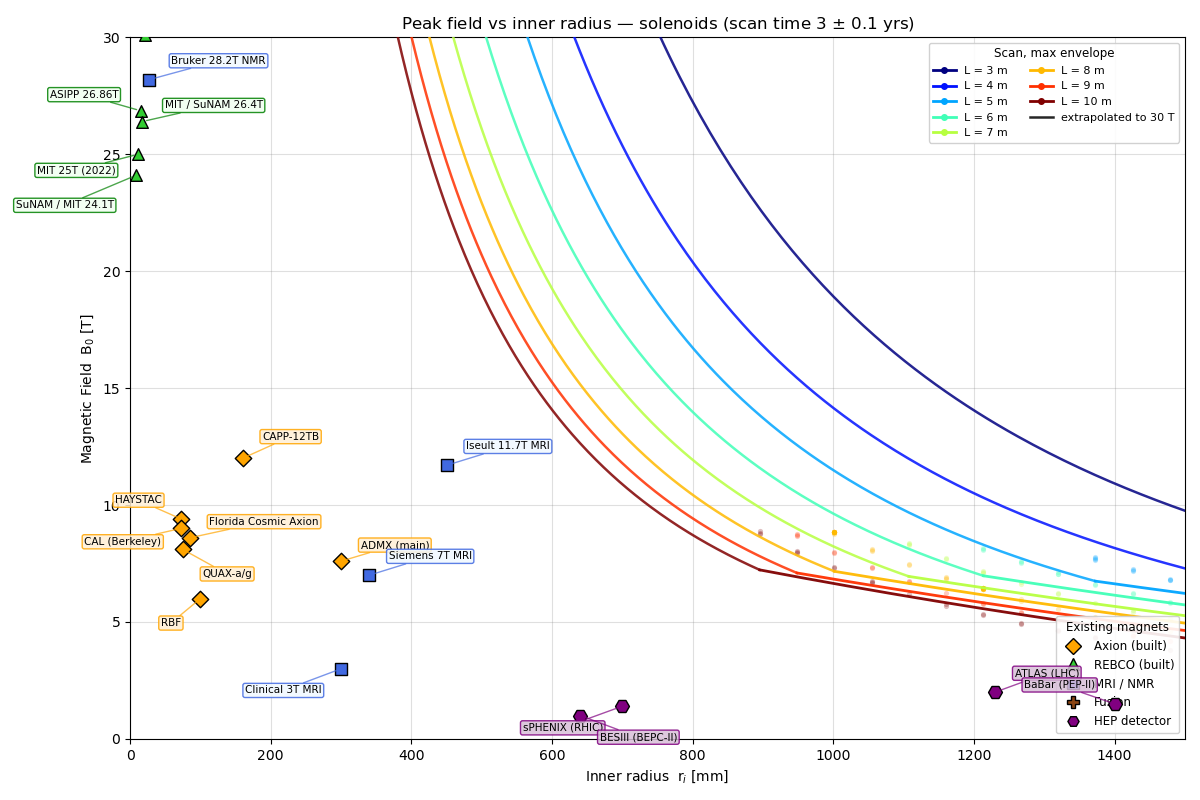

In [20]:
# -------------------------------------------------------------------------
# MAGNET LANDSCAPE PLOT
#   Field (y) vs Inner Radius (x)
#   Background = parametric scan at ~4 years scan time (all lengths)
#   One fitted curve per solenoid length, coloured jet (small = blue, large = red)
#   Each curve is EXTRAPOLATED to small r_i until it reaches B_EXTEND_MAX,
#   drawn dashed over the extrapolated span.
#   Linear axes, two legends (lengths / magnet categories)
# -------------------------------------------------------------------------
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.lines import Line2D
import numpy as np
import glob
import pandas as pd

# -------------------------------------------------------------------------
# 0. USER CONTROLS
# -------------------------------------------------------------------------
target_scan_years = 3       # scan time to select
scan_tol_years    = 0.1    # +/- tolerance around the target

SHOW_BACKGROUND  = True     # draw the raw scan points
SHOW_POINTS      = True     # faint scatter underlay
SHOW_FITS        = True     # fitted curve per length
ANNOTATE_MAGNETS = True

ENVELOPE = 'max'            # 'max' | 'min' | 'none'  -> how to collapse th at fixed ri
FIT_MODE = 'poly'           # 'poly' | 'spline' | 'raw'
POLY_DEG = 3                # polynomial degree for FIT_MODE='poly'
SPLINE_SMOOTH = None        # None -> auto; float -> UnivariateSpline s parameter
N_FIT = 300                 # points used to draw each fitted curve

# --- extrapolation of the trend lines ------------------------------------
EXTEND_FITS    = True       # continue each curve past the data
B_EXTEND_MAX   = 30.0       # stop the extrapolation at this field [T]
EXTRAP_MODE    = 'loglog'   # 'loglog' | 'tangent' | 'same' -> how to continue
EXTRAP_N_TAIL  = 8          # data points at the low-ri end used to set the trend
EXTRAP_X_MIN   = 1.0        # never extrapolate below this radius [mm]
EXTRAP_STYLE   = dict(ls='-', lw=1.8, alpha=0.85)
N_EXT          = 400        # sampling of the extrapolated span

figB_xlim = (0, 1500)       # inner radius [mm]   (linear)
figB_ylim = (0, 30)         # field [T]

# -------------------------------------------------------------------------
# 1. LOAD PARAMETRIC SCAN DATA
# -------------------------------------------------------------------------
file_list = glob.glob('thickness_grids_L*.csv')
if file_list:
    df_all = pd.concat((pd.read_csv(f) for f in file_list), ignore_index=True)
    lo = target_scan_years - scan_tol_years
    hi = target_scan_years + scan_tol_years
    df_filtered = df_all[(df_all['scan'] >= lo) &
                         (df_all['scan'] <= hi)].reset_index(drop=True)
    print(f"{len(df_filtered)} scan points with scan in [{lo:.2f}, {hi:.2f}] yrs")
    if len(df_filtered) and 'solenoid_length_m' in df_filtered.columns:
        print("lengths present:",
              np.sort(df_filtered['solenoid_length_m'].unique()))
    if df_filtered.empty:
        print("WARNING: no points in the tolerance window -> widen scan_tol_years.")
        SHOW_BACKGROUND = False
else:
    print("WARNING: no 'thickness_grids_L*.csv' found -> background disabled.")
    df_filtered = pd.DataFrame(columns=['ri', 'th', 'b0', 'v', 'scan',
                                        'length_tape_km', 'pancake_length_m',
                                        'solenoid_length_m'])
    SHOW_BACKGROUND = False


# -------------------------------------------------------------------------
# 1b. FIT HELPERS
# -------------------------------------------------------------------------
def make_envelope(sub, mode=ENVELOPE):
    """Collapse the (ri, th) cloud of one length into a single b0(ri) curve."""
    if mode == 'none':
        g = sub[['ri', 'b0']].sort_values('ri')
        return g['ri'].to_numpy(), g['b0'].to_numpy()
    agg = 'max' if mode == 'max' else 'min'
    g = sub.groupby('ri', as_index=False)['b0'].agg(agg).sort_values('ri')
    return g['ri'].to_numpy(), g['b0'].to_numpy()


def fit_eval(x, y, mode=FIT_MODE, deg=POLY_DEG):
    """
    Fit the envelope and return (f, xmin, xmax) where f(xq) evaluates the fit.
    Returning a callable rather than a sampled curve is what lets the same
    fit be pushed outside the data range later.
    """
    x = np.asarray(x, float)
    y = np.asarray(y, float)
    ok = np.isfinite(x) & np.isfinite(y)
    x, y = x[ok], y[ok]
    if x.size == 0:
        return None, np.nan, np.nan

    order = np.argsort(x)
    x, y = x[order], y[order]

    if mode == 'raw' or x.size < 4:
        def f(xq, _x=x, _y=y):
            return np.interp(xq, _x, _y, left=np.nan, right=np.nan)
        return f, x.min(), x.max()

    if mode == 'spline':
        try:
            from scipy.interpolate import UnivariateSpline
            xu, idx = np.unique(x, return_index=True)
            yu = y[idx]
            k = min(3, xu.size - 1)
            s = (SPLINE_SMOOTH if SPLINE_SMOOTH is not None
                 else len(xu) * np.var(yu) * 1e-3)
            spl = UnivariateSpline(xu, yu, k=k, s=s)
            return spl, float(xu.min()), float(xu.max())
        except Exception as exc:
            print(f"  spline failed ({exc}) -> falling back to polynomial")

    d = int(min(deg, x.size - 1))
    coef = np.polyfit(x, y, d)
    return (lambda xq, _c=coef: np.polyval(_c, xq)), float(x.min()), float(x.max())


def make_extrapolator(x, y, f_fit, x0, mode=EXTRAP_MODE, n_tail=EXTRAP_N_TAIL):
    """
    Build g(xq) that continues the trend below x0. Whatever the mode, g is
    forced through (x0, f_fit(x0)) so the dashed part joins the solid one.
    """
    x = np.asarray(x, float)
    y = np.asarray(y, float)
    ok = np.isfinite(x) & np.isfinite(y)
    x, y = x[ok], y[ok]
    order = np.argsort(x)
    x, y = x[order], y[order]
    y0 = float(f_fit(x0))

    if mode == 'same':
        return f_fit

    if mode == 'loglog' and x.size >= 2:
        # power law y = A x^b through the lowest-radius points; monotone and
        # far better behaved outside the data than a cubic
        m = min(n_tail, x.size)
        xt, yt = x[:m], y[:m]
        good = (xt > 0) & (yt > 0)
        if good.sum() >= 2:
            b = np.polyfit(np.log(xt[good]), np.log(yt[good]), 1)[0]
            A = y0 / (x0 ** b)
            return lambda xq, _A=A, _b=b: _A * np.asarray(xq, float) ** _b

    # tangent: straight continuation with the slope of the fit at x0
    h = max(1e-6, 1e-3 * max(abs(x0), 1.0))
    slope = float((f_fit(x0 + h) - f_fit(x0 - h)) / (2 * h))
    return lambda xq, _s=slope, _x0=x0, _y0=y0: _y0 + _s * (np.asarray(xq, float) - _x0)


def trim_from_right(xs, ys, b_max):
    """
    Keep the contiguous run ending at the right-hand end for which y is finite
    and <= b_max, then interpolate the exact b_max crossing so the dashed line
    terminates on the 30 T level instead of overshooting it.
    """
    bad = ~np.isfinite(ys) | (ys > b_max)
    if not bad.any():
        return xs, ys
    i = int(np.max(np.nonzero(bad)[0]))       # last violating index
    if i >= len(xs) - 1:
        return np.array([]), np.array([])
    xs_k, ys_k = xs[i + 1:], ys[i + 1:]
    # linear crossing between the violating point and the first kept point
    if np.isfinite(ys[i]) and ys[i] != ys_k[0]:
        t = (b_max - ys_k[0]) / (ys[i] - ys_k[0])
        x_cross = xs_k[0] + t * (xs[i] - xs_k[0])
        xs_k = np.concatenate(([x_cross], xs_k))
        ys_k = np.concatenate(([b_max], ys_k))
    return xs_k, ys_k


# -------------------------------------------------------------------------
# 1c. INTERACTIVE PICK ANNOTATION (handles several scatter objects)
# -------------------------------------------------------------------------
def setup_pick_annotation(fig, ax, pairs):
    """pairs = list of (scatter_artist, dataframe) with matching row order."""
    annot = ax.annotate("", xy=(0, 0), xytext=(15, 15), textcoords="offset points",
                        bbox=dict(boxstyle="round", fc="w", alpha=0.9),
                        fontsize=8, zorder=20)
    annot.set_visible(False)
    lookup = {id(artist): sub for artist, sub in pairs}

    def on_pick(event):
        sub = lookup.get(id(event.artist))
        if sub is None:
            return
        ind = event.ind[0]
        row = sub.iloc[ind]
        x, y = event.artist.get_offsets()[ind]
        annot.xy = (x, y)
        annot.set_text(f"L={row['solenoid_length_m']:.1f} m\n"
                       f"Ri={row['ri']:.3f} m, Th={row['th']:.3f} m\n"
                       f"B0={row['b0']:.2f} T\n"
                       f"Total SC={row['length_tape_km']:.1f} km\n"
                       f"Pancake SC={row['pancake_length_m']:.1f} m\n"
                       f"Scan={row['scan']:.2f} yrs\n"
                       f"Vol={row.get('v', 0):.3g} m3")
        annot.set_visible(True)
        fig.canvas.draw_idle()

    fig.canvas.mpl_connect("pick_event", on_pick)


# -------------------------------------------------------------------------
# 2. MAGNET DATABASE  (name, category, ri [mm], field volume [m3], B0 [T])
# -------------------------------------------------------------------------
MAGNETS = [
    # ---------------- Axion / dark matter (built) ------------------------
    ("CAPP-12TB",             "Axion (built)",     160.0, 0.021,    12.00),
    ("ORGAN",                 "Axion (built)",     None,  4.8e-5,   11.50),
    ("HAYSTAC",               "Axion (built)",      73.0, 0.009,     9.40),
    ("CAL (Berkeley)",        "Axion (built)",      72.0, 0.007,     9.00),
    ("Florida Cosmic Axion",  "Axion (built)",      85.0, 0.008,     8.60),
    ("QUAX-a/g",              "Axion (built)",      75.0, 0.009,     8.10),
    ("ADMX (main)",           "Axion (built)",     300.0, 0.283,     7.60),
    ("RBF",                   "Axion (built)",     100.0, 0.011,     6.00),

    # ---------------- REBCO high field, built ----------------------------
    ("LBC9 (NHMFL) 48.7T",    "REBCO (built)",       7.0, 1.0e-5,   48.70),
    ("LBC3 (NHMFL) 45.5T",    "REBCO (built)",       7.0, 8.0e-6,   45.50),
    ("LBC4-5 (NHMFL) 44T",    "REBCO (built)",       7.0, 8.0e-6,   44.00),
    ("LBC6 (NHMFL) 43T",      "REBCO (built)",       7.0, 8.0e-6,   43.00),
    ("LBC2 (NHMFL) 42.5T",    "REBCO (built)",       7.0, 8.0e-6,   42.50),
    ("LBC1 (NHMFL) 40.2T",    "REBCO (built)",       7.0, 8.0e-6,   40.20),
    ("NOUGAT 32.5T",          "REBCO (built)",      19.0, 2.4e-4,   32.50),
    ("ASIPP 32.4T",           "REBCO (built)",       8.5, 4.0e-5,   32.40),
    ("IEE CAS 32.35T",        "REBCO (built)",      20.0, 2.0e-4,   32.35),
    ("NHMFL 32T all-SC",      "REBCO (built)",      21.5, 2.0e-4,   32.00),
    ("RIKEN 31.4T",           "REBCO (built)",       8.5, 5.0e-5,   31.40),
    ("IEE CAS 30.1T",         "REBCO (built)",      21.5, 2.0e-4,   30.10),
    ("ASIPP 26.86T",          "REBCO (built)",      15.0, 1.5e-4,   26.86),
    ("MIT / SuNAM 26.4T",     "REBCO (built)",      17.5, 3.0e-4,   26.40),
    ("MIT 25T (2022)",        "REBCO (built)",      11.2, 1.5e-4,   25.00),
    ("SuNAM / MIT 24.1T",     "REBCO (built)",       8.5, 5.0e-5,   24.10),

    # ---------------- MRI / NMR ------------------------------------------
    ("Bruker 28.2T NMR",      "MRI / NMR",          27.0, None,     28.19),
    ("Iseult 11.7T MRI",      "MRI / NMR",         450.0, None,     11.70),
    ("Siemens 7T MRI",        "MRI / NMR",         340.0, 0.835,     7.00),
    ("Clinical 3T MRI",       "MRI / NMR",         300.0, 0.452,     3.00),

    # ---------------- Fusion (solenoid) ----------------------------------
    ("ITER Central Solenoid", "Fusion",           2060.0, 158.25,   13.50),

    # ---------------- HEP detector solenoids ------------------------------
    ("CMS (LHC)",             "HEP detector",     2950.0, 341.75,    4.00),
    ("ATLAS (LHC)",           "HEP detector",     1230.0,  27.57,    2.00),
    ("Belle II",              "HEP detector",     1700.0,  35.74,    1.50),
    ("BaBar (PEP-II)",        "HEP detector",     1400.0,  21.63,    1.50),
    ("sPHENIX (RHIC)",        "HEP detector",      700.0,   1.69,    1.40),
    ("BESIII (BEPC-II)",      "HEP detector",      640.0,   4.53,    1.00),
    ("KLOE (DAFNE)",          "HEP detector",     2450.0,  92.40,    0.60),
    ("ALICE (LHC)",           "HEP detector",     5780.0, 740.99,    0.50),
    ("STAR (RHIC)",           "HEP detector",     2500.0, 134.50,    0.50),
]

df_mag = pd.DataFrame(MAGNETS, columns=['name', 'category', 'ri_mm', 'v_m3', 'b0'])

# -------------------------------------------------------------------------
# 3. STYLE PER CATEGORY
# -------------------------------------------------------------------------
STYLE = {
    'Axion (built)':    dict(color='orange',      marker='D', s=70,  box='papayawhip',  edge='orange'),
    'REBCO (built)':    dict(color='limegreen',   marker='^', s=70,  box='honeydew',    edge='green'),
    'MRI / NMR':        dict(color='royalblue',   marker='s', s=80,  box='aliceblue',   edge='royalblue'),
    'Fusion':           dict(color='saddlebrown', marker='P', s=110, box='linen',       edge='saddlebrown'),
    'HEP detector':     dict(color='purple',      marker='H', s=100, box='thistle',     edge='purple'),
}
DEFAULT_STYLE = dict(color='gray', marker='o', s=60, box='white', edge='gray')

# -------------------------------------------------------------------------
# 4. LABEL OFFSETS  (x_off, y_off, ha, va)
# -------------------------------------------------------------------------
OFFSETS_RI = {
    'LBC9 (NHMFL) 48.7T':   ( 16,   6, 'left',  'bottom'),
    'LBC3 (NHMFL) 45.5T':   ( 16,   0, 'left',  'center'),
    'LBC4-5 (NHMFL) 44T':   ( 16,  -6, 'left',  'top'),
    'LBC6 (NHMFL) 43T':     (-16,   6, 'right', 'bottom'),
    'LBC2 (NHMFL) 42.5T':   (-16,  -2, 'right', 'center'),
    'LBC1 (NHMFL) 40.2T':   (-16, -12, 'right', 'top'),
    'NOUGAT 32.5T':         ( 16,  14, 'left',  'bottom'),
    'ASIPP 32.4T':          (-16,  12, 'right', 'bottom'),
    'IEE CAS 32.35T':       ( 16,   8, 'left',  'bottom'),
    'NHMFL 32T all-SC':     ( 16,  -2, 'left',  'center'),
    'RIKEN 31.4T':          (-16,  -8, 'right', 'top'),
    'IEE CAS 30.1T':        ( 16, -14, 'left',  'top'),
    'Bruker 28.2T NMR':     ( 16,  10, 'left',  'bottom'),
    'ASIPP 26.86T':         (-16,   8, 'right', 'bottom'),
    'MIT / SuNAM 26.4T':    ( 16,   8, 'left',  'bottom'),
    'MIT 25T (2022)':       (-16,  -8, 'right', 'top'),
    'SuNAM / MIT 24.1T':    (-16, -18, 'right', 'top'),
    'CAPP-12TB':            ( 14,  12, 'left',  'bottom'),
    'Iseult 11.7T MRI':     ( 14,  10, 'left',  'bottom'),
    'HAYSTAC':              (-14,  10, 'right', 'bottom'),
    'CAL (Berkeley)':       (-14,  -6, 'right', 'top'),
    'Florida Cosmic Axion': ( 14,   8, 'left',  'bottom'),
    'QUAX-a/g':             ( 14, -14, 'left',  'top'),
    'ADMX (main)':          ( 14,   8, 'left',  'bottom'),
    'RBF':                  (-14, -14, 'right', 'top'),
    'ITER Central Solenoid':( 14,  12, 'left',  'bottom'),
    'Siemens 7T MRI':       ( 14,  10, 'left',  'bottom'),
    'CMS (LHC)':            ( 14,  10, 'left',  'bottom'),
    'Clinical 3T MRI':      (-14, -12, 'right', 'top'),
    'ATLAS (LHC)':          ( 14,  10, 'left',  'bottom'),
    'Belle II':             ( 14,  10, 'left',  'bottom'),
    'BaBar (PEP-II)':       (-14,  10, 'right', 'bottom'),
    'sPHENIX (RHIC)':       (-14, -12, 'right', 'top'),
    'BESIII (BEPC-II)':     ( 14, -12, 'left',  'top'),
    'KLOE (DAFNE)':         ( 14, -12, 'left',  'top'),
    'ALICE (LHC)':          (-14,  12, 'right', 'bottom'),
    'STAR (RHIC)':          ( 14, -14, 'left',  'top'),
}

# -------------------------------------------------------------------------
# 5. FIGURE : FIELD vs INNER RADIUS
# -------------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(12, 8))

pick_pairs = []
length_handles = []
any_extrap = False

if SHOW_BACKGROUND and len(df_filtered):
    lengths = np.sort(df_filtered['solenoid_length_m'].unique())
    n = len(lengths)
    try:
        cmap = plt.get_cmap('jet')
    except Exception:
        cmap = mpl.cm.get_cmap('jet')
    colors = [cmap(i / max(n - 1, 1)) for i in range(n)]  # small = blue, large = red

    if SHOW_FITS and EXTEND_FITS:
        print(f"extrapolating trend lines to {B_EXTEND_MAX:g} T "
              f"({EXTRAP_MODE}, tail of {EXTRAP_N_TAIL} points):")

    for L, col in zip(lengths, colors):
        sub = df_filtered[df_filtered['solenoid_length_m'] == L].reset_index(drop=True)

        # raw points (faint, pickable, not in the legend)
        if SHOW_POINTS:
            sc = ax.scatter(sub['ri'] * 1000.0, sub['b0'],
                            color=col, alpha=0.25, s=14, linewidths=0,
                            picker=5, zorder=2)
            pick_pairs.append((sc, sub))

        if not SHOW_FITS:
            length_handles.append(Line2D([], [], color=col, lw=2.0,
                                         marker='o', markersize=4,
                                         label=f'L = {L:g} m'))
            continue

        # ---- fit through the envelope, in mm --------------------------------
        xe, ye = make_envelope(sub)
        xe = xe * 1000.0
        f, x_lo, x_hi = fit_eval(xe, ye)
        if f is None or not np.isfinite(x_lo):
            continue

        # solid part: over the data range, clipped at B_EXTEND_MAX
        xs = np.linspace(x_lo, x_hi, N_FIT)
        ys = np.asarray(f(xs), float)
        xs_s, ys_s = trim_from_right(xs, ys, B_EXTEND_MAX)
        if len(xs_s):
            ax.plot(xs_s, ys_s, color=col, lw=2.0, alpha=0.95, zorder=4)

        # dashed part: continue below the data until B_EXTEND_MAX
        if EXTEND_FITS:
            x_floor = max(EXTRAP_X_MIN,
                          figB_xlim[0] if figB_xlim and figB_xlim[0] else EXTRAP_X_MIN)
            if x_floor < x_lo:
                g = make_extrapolator(xe, ye, f, x_lo)
                xg = np.linspace(x_floor, x_lo, N_EXT)
                yg = np.asarray(g(xg), float)
                xg, yg = trim_from_right(xg, yg, B_EXTEND_MAX)
                if len(xg) > 1:
                    ax.plot(xg, yg, color=col, zorder=3, **EXTRAP_STYLE)
                    any_extrap = True
                    print(f"  L = {L:g} m : {yg[-1]:.2f} T at r_i = {xg[-1]:.0f} mm "
                          f"-> {yg[0]:.2f} T at r_i = {xg[0]:.0f} mm")
                else:
                    print(f"  L = {L:g} m : extrapolation empty "
                          f"(curve already above {B_EXTEND_MAX:g} T at r_i = {x_lo:.0f} mm)")

        length_handles.append(Line2D([], [], color=col, lw=2.0,
                                     marker='o', markersize=4,
                                     label=f'L = {L:g} m'))

# --- magnet database ------------------------------------------------------
sub_mag = df_mag.dropna(subset=['ri_mm', 'b0'])
cat_handles = {}
for _, row in sub_mag.iterrows():
    st = STYLE.get(row['category'], DEFAULT_STYLE)
    ax.scatter(row['ri_mm'], row['b0'], color=st['color'], edgecolor='black',
               s=st['s'], marker=st['marker'], zorder=6)
    if row['category'] not in cat_handles:
        cat_handles[row['category']] = Line2D([], [], linestyle='none',
                                              marker=st['marker'],
                                              markerfacecolor=st['color'],
                                              markeredgecolor='black',
                                              markersize=8,
                                              label=row['category'])
    if ANNOTATE_MAGNETS:
        x_off, y_off, ha, va = OFFSETS_RI.get(row['name'], (14, 8, 'left', 'bottom'))
        ax.annotate(row['name'], xy=(row['ri_mm'], row['b0']),
                    xytext=(x_off, y_off), textcoords='offset points',
                    ha=ha, va=va, fontsize=7.5, zorder=7, color='black',
                    bbox=dict(boxstyle="round,pad=0.2", facecolor=st['box'],
                              alpha=0.85, edgecolor=st['edge']),
                    arrowprops=dict(arrowstyle="-", color=st['edge'],
                                    alpha=0.7, shrinkA=0, shrinkB=3))

# --- cosmetics ------------------------------------------------------------
ax.set_xlabel('Inner radius  r$_i$ [mm]')
ax.set_ylabel('Magnetic Field  B$_0$ [T]')
ax.set_title(f'Peak field vs inner radius — solenoids '
             f'(scan time {target_scan_years:g} $\\pm$ {scan_tol_years:g} yrs)')
if figB_xlim: ax.set_xlim(figB_xlim)
if figB_ylim: ax.set_ylim(figB_ylim)
ax.grid(True, which='both', linestyle='-', color='gray', alpha=0.25)

# two legends: solenoid lengths (lines) and magnet categories (markers)
if length_handles:
    handles1 = list(length_handles)
    if any_extrap:
        handles1.append(Line2D([], [], color='black',
                               label=f'extrapolated to {B_EXTEND_MAX:g} T',
                               **EXTRAP_STYLE))
    leg1 = ax.legend(handles=handles1, loc='upper right',
                     title=f'Scan, {ENVELOPE} envelope', fontsize=8,
                     title_fontsize=8.5, framealpha=0.9, ncol=2)
    ax.add_artist(leg1)
    loc2 = 'lower right'
else:
    loc2 = 'upper right'

if cat_handles:
    ax.legend(handles=list(cat_handles.values()), loc=loc2,
              title='Existing magnets', fontsize=8.5,
              title_fontsize=8.5, framealpha=0.9)

if pick_pairs:
    setup_pick_annotation(fig, ax, pick_pairs)

fig.tight_layout()

# -------------------------------------------------------------------------
# 6. OPTIONAL: dump the curated table
# -------------------------------------------------------------------------
df_mag.to_csv('solenoid_landscape.csv', index=False)

plt.show()

# Pareto Fronts by Magnet Length — fitting, fixed-scan-time extraction, banded plot

Reads every `thickness_grids_L*.csv`, builds a per-magnet Pareto front in
(REBCO tape length, scan time), fits each front, extracts real designs at a set
of target scan times, and renders one aggregate figure plus one PNG per magnet.

## Pass 1 — fronts and fits

Rows are filtered to `SCAN_MIN <= scan <= SCAN_MAX`, sorted by
`(length_tape_km, scan)`, and swept once keeping any row whose scan time beats
every cheaper design. Because the sort breaks ties on scan ascending, the
fastest design at a given tape length always wins; `KEEP_TIES` additionally
retains equal-scan designs at higher tape cost. The retained rows keep their
full design vector, so `saved_pareto_fronts.csv` carries every grid column plus
`source_file` and `pareto_rank`.

Each front with three or more unique x-values is fitted with both `power_law`
and `exponential_decay`, and the lower sum of squared residuals wins. Two-point
fronts, and fronts where both `curve_fit` calls raise, fall back to a Pchip
spline. Fitted coefficients are written with their `x_fit_min`/`x_fit_max`
validity range, which callers must respect: neither functional form is
constrained to stay monotone or positive outside the fitted interval.

## Fixed scan times

For each magnet and each entry in `TARGET_SCANS`, designs within
`target ± margin` are collected from either the front or the full windowed grid
(`SEARCH_POOL`). `PICK_RULE` selects one: `closest` minimises absolute scan
error, `cheapest` minimises tape, `cheapest_not_slower` minimises tape among
designs at or faster than target. Empty windows either return the nearest
design flagged `outside_window`, or a stub row flagged `no_match`. Outputs are
the selection, optionally every in-window candidate, and a target × magnet-length
pivot of tape cost.

## Pass 2 — plotting

Curves are sorted by magnet length and coloured through a single `Normalize`
shared with the colourbar. Neighbouring curves are evaluated on a common x-grid
with constant extrapolation beyond each curve's own data range and filled
against each other, giving contiguous bands only while the curves do not cross.

> `SCAN_MIN` must sit below `min(TARGET_SCANS) - SCAN_MARGIN`, or the first
> target's acceptance window is partly outside the data and the fallback
> "nearest design" is nearest only within the filter.
>
> The Pareto front is the front of the scan-filtered subset, not of the grid.
>
> `EXPORT_COLUMNS` also prunes the frame used as the `'pareto'` search pool; it
> must retain `scan` and `length_tape_km`.
>
> Magnets with fewer than two unique front points are written to the CSVs but
> not plotted. Spline-fallback magnets are omitted from the equations CSV.
>
> With `MARGIN_MODE = 'rel'` the windows for targets 3 and 4 overlap, so one
> design can be selected for both.

matplotlib backend: widget


/var/folders/8k/rnt65xzx4ml1894t3n7wmjzw0000gn/T/ipykernel_86576/2516111537.py:82: RuntimeWarning: overflow encountered in exp
  return a * np.exp(-b * x) + c
/var/folders/8k/rnt65xzx4ml1894t3n7wmjzw0000gn/T/ipykernel_86576/2516111537.py:82: RuntimeWarning: overflow encountered in exp
  return a * np.exp(-b * x) + c
/var/folders/8k/rnt65xzx4ml1894t3n7wmjzw0000gn/T/ipykernel_86576/2516111537.py:82: RuntimeWarning: overflow encountered in multiply
  return a * np.exp(-b * x) + c
/var/folders/8k/rnt65xzx4ml1894t3n7wmjzw0000gn/T/ipykernel_86576/2516111537.py:82: RuntimeWarning: overflow encountered in exp
  return a * np.exp(-b * x) + c
/var/folders/8k/rnt65xzx4ml1894t3n7wmjzw0000gn/T/ipykernel_86576/2516111537.py:82: RuntimeWarning: overflow encountered in exp
  return a * np.exp(-b * x) + c
/var/folders/8k/rnt65xzx4ml1894t3n7wmjzw0000gn/T/ipykernel_86576/2516111537.py:82: RuntimeWarning: overflow encountered in exp
  return a * np.exp(-b * x) + c
/var/folders/8k/rnt65xzx4ml1894t3n7wmjzw0

Saved 2558 Pareto points with 70 columns to 'saved_pareto_fronts.csv'
  columns: source_file, pareto_rank, solenoid_length_m, length_tape_km, scan, row_i, col_j, schema, n_pc, n_par, ri, rf, th, v, valid, b0, v_bore, je_coil, je_tape, je_max, j_crit, je_mech, b0_mech, je_closed, stress, sigma_struct, sigma_tape, util, f_struct, f_struct_tape, f_filler, f_tape_min, f_tape_built, fill, n_tp_min, n_tp, n_bund, n_tape, n_tot, n_par_min, pitch, pitch_turn, i0, i_tape, i_max, i_margin, length_tape, em_tot, em_dump, l_self, l_dump, r_ee, u_ee, tau_ee, miits, j_cu_max, j_cu, gamma_op, f_cu_req, f_cu_have, f_cu_add, t_cu_add, m_cu, n_eval, binding_code, feasible, converged, binding, pancake_length_m, piece_length_m
Fit parameters saved to 'saved_pareto_equations.csv'

Fixed scan times: 31/32 magnets matched inside the margin -> 'scan_time_points.csv' (79 columns)
  L=8.0  target=6 yr: no design within +/-0.2 yr; nearest is 6.218 yr at 204.7 km
Summary (REBCO km vs magnet length) -> 'scan_time_s

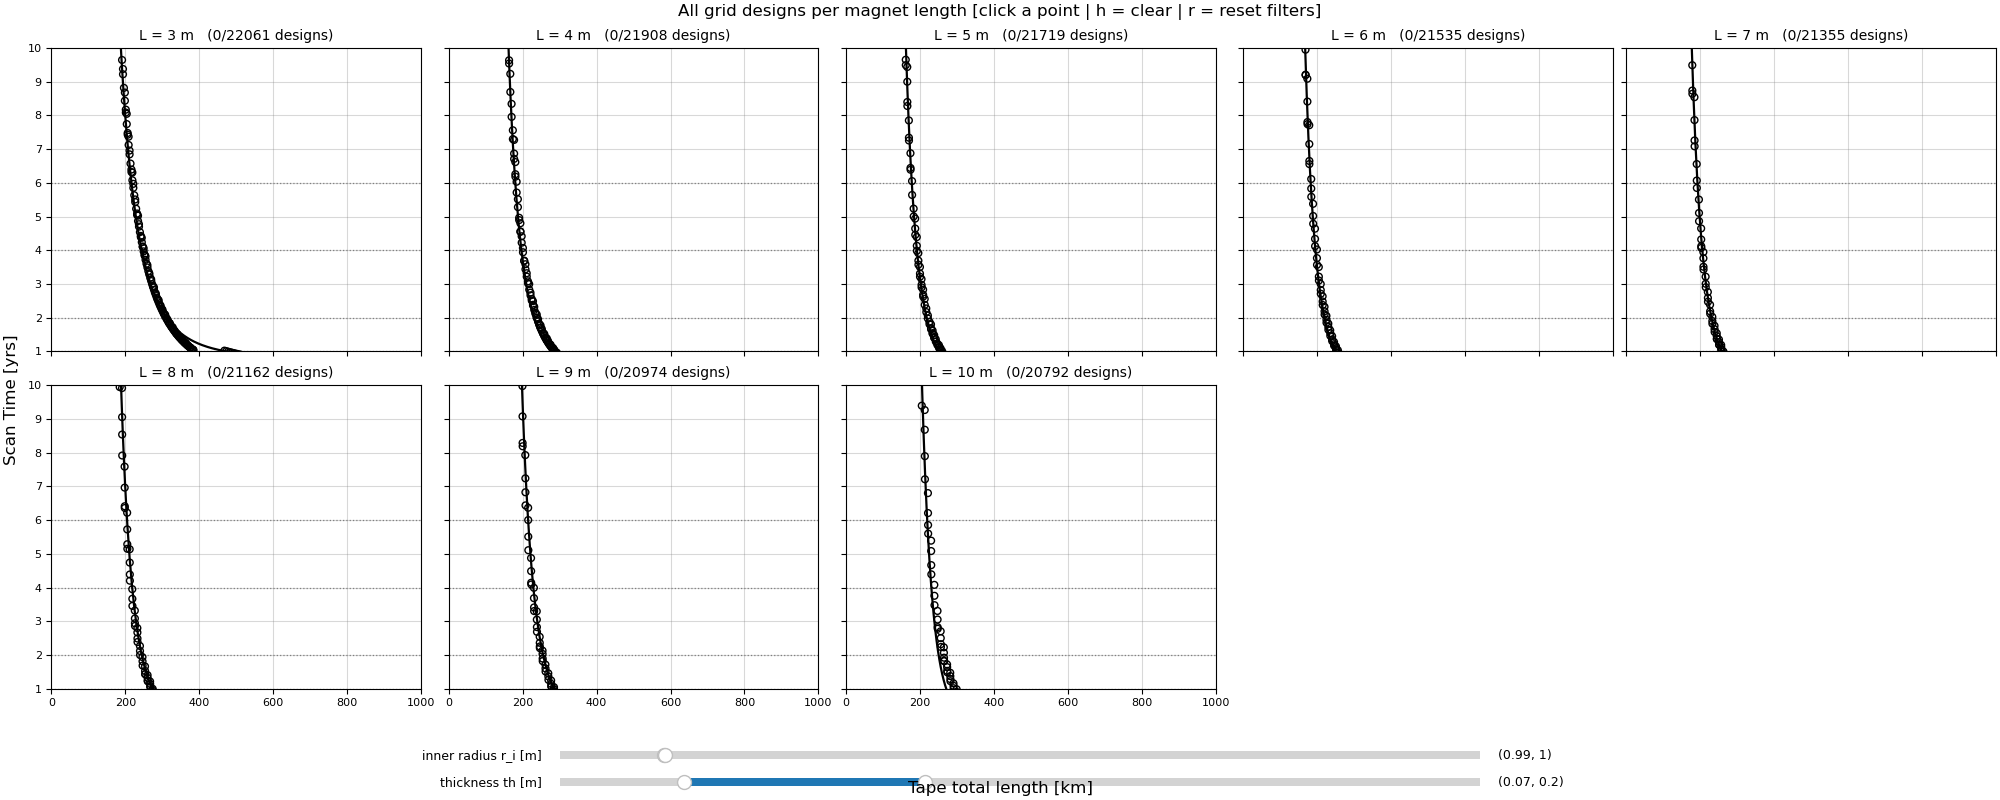

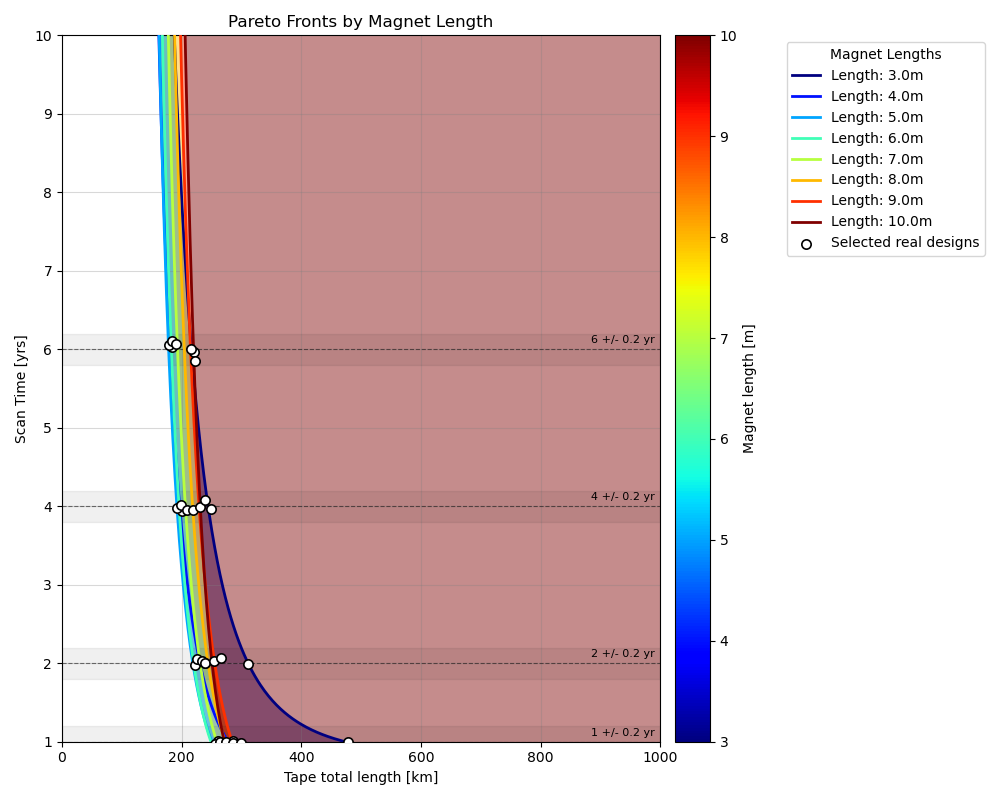

In [ ]:
%matplotlib widget

# ---------------------------------------------------------------------------
# backend selection MUST happen before pyplot is imported
# ---------------------------------------------------------------------------
import matplotlib

_CURRENT = matplotlib.get_backend()
_NON_INTERACTIVE = ('agg', 'pdf', 'ps', 'svg', 'cairo', 'template')
if _CURRENT.lower() in _NON_INTERACTIVE or 'inline' in _CURRENT.lower():
    for _cand in ('qtagg', 'qt5agg', 'tkagg', 'macosx'):
        try:
            matplotlib.use(_cand, force=True)
            break
        except Exception:
            continue

import matplotlib.pyplot as plt
import matplotlib as mpl
import pandas as pd
import numpy as np
import glob
import os
import re
from scipy.optimize import curve_fit
from scipy.interpolate import PchipInterpolator

BACKEND = matplotlib.get_backend()
INTERACTIVE = not (BACKEND.lower() in _NON_INTERACTIVE or 'inline' in BACKEND.lower())
print(f"matplotlib backend: {BACKEND}"
      f"{'' if INTERACTIVE else '   <-- NOT interactive, clicking will not work'}")
if not INTERACTIVE:
    print("  In a notebook run  %matplotlib qt  (or install ipympl and use "
          "%matplotlib widget).  In a terminal install PyQt5:  pip install PyQt5")

# ----------------------------- user settings --------------------------------
CMAP        = plt.cm.jet
FILL_ALPHA  = 0.45
Y_TOP       = 10
Y_BOTTOM    = 1
X_LIM       = (0.0, 1000.0)
FILL_TO_TOP = True
BAND_FROM_LOWER_LENGTH = True
SCAN_MIN, SCAN_MAX = 0, 100
KEEP_TIES   = False
EXPORT_COLUMNS = None

# ---- fixed scan-time extraction --------------------------------------------
TARGET_SCANS     = (2, 4, 6)
SCAN_MARGIN      = 0.2
MARGIN_MODE      = 'abs'          # 'abs' | 'rel'
SEARCH_POOL      = 'pareto'       # 'pareto' | 'grid'
PICK_RULE        = 'closest'      # 'closest' | 'cheapest' | 'cheapest_not_slower'
FALLBACK_NEAREST = True
KEEP_CANDIDATES  = True
SELECTED_CSV     = 'scan_time_points.csv'
CANDIDATES_CSV   = 'scan_time_candidates.csv'
SUMMARY_CSV      = 'scan_time_summary.csv'

# ---- overview figure --------------------------------------------------------
NROWS, NCOLS    = 2, 5
POINT_COLOR     = 'tab:blue'
APPLY_LIMITS    = True
SHARE_AXES      = True
OVERLAY_FRONT   = True
FEASIBLE_ONLY   = False
CLICK_RADIUS_PX = 15        # how close (in screen pixels) a click must be
PRINT_ALL_HITS  = False
MAKE_INDIVIDUAL = False
SHOW_COLS       = ['b0', 'ri', 'th', 'solenoid_length_m', 'je_coil', 'je_tape',
                   'f_cu_add', 'f_struct', 'length_tape_km', 'scan']
OVERVIEW_NAME   = 'grid_points_all_lengths.png'
# -----------------------------------------------------------------------------


def power_law(x, a, b, c):
    x_safe = np.maximum(x, 1e-5)
    return a * (x_safe ** -b) + c


def exponential_decay(x, a, b, c):
    return a * np.exp(-b * x) + c


def safe_tag(text):
    """Filesystem-safe token used for the individual figure filenames."""
    return re.sub(r'[^0-9A-Za-z_-]+', '_', str(text)).strip('_')


def margin_for(target):
    """Half-width of the acceptance window around a target scan time."""
    return SCAN_MARGIN * target if MARGIN_MODE == 'rel' else SCAN_MARGIN


file_list = sorted(glob.glob('thickness_grids_L*.csv'))
if not file_list:
    raise SystemExit("No files matching 'thickness_grids_L*.csv' were found.")

all_pareto_frames = []
all_fit_equations = []
curves = []
magnet_pools = []

# =============================================================================
# PASS 1 - read the data, build the Pareto fronts and fit them
# =============================================================================
for file_path in file_list:
    df_all = pd.read_csv(file_path)
    base_name = os.path.basename(file_path)

    missing = {'length_tape_km', 'scan'} - set(df_all.columns)
    if missing:
        print(f"  skipping {base_name}: missing column(s) {sorted(missing)}")
        continue

    if 'solenoid_length_m' in df_all.columns:
        length_val = df_all['solenoid_length_m'].iloc[0]
        label_name = f'Length: {length_val}m'
    else:
        length_val = base_name
        label_name = str(length_val)

    df_filtered = df_all[(df_all['scan'] >= SCAN_MIN) &
                         (df_all['scan'] <= SCAN_MAX)].reset_index(drop=True)
    if len(df_filtered) == 0:
        print(f"  skipping {base_name}: no rows inside the scan-time window")
        continue

    df_sorted = df_filtered.sort_values(by=['length_tape_km', 'scan'])

    # ---- dominance filter ---------------------------------------------------
    pareto_idx = []
    min_y = float('inf')
    for index, row in df_sorted.iterrows():
        y = row['scan']
        if y < min_y:
            pareto_idx.append(index)
            min_y = y
        elif KEEP_TIES and y == min_y:
            pareto_idx.append(index)

    if not pareto_idx:
        continue

    df_pareto = df_sorted.loc[pareto_idx].copy()
    if EXPORT_COLUMNS is not None:
        keep = [c for c in EXPORT_COLUMNS if c in df_pareto.columns]
        df_pareto = df_pareto[keep]
    df_pareto['solenoid_length_m'] = length_val
    df_pareto.insert(0, 'source_file', base_name)
    df_pareto.insert(1, 'pareto_rank', np.arange(len(df_pareto)))
    df_pareto = df_pareto.reset_index(drop=True)
    all_pareto_frames.append(df_pareto)

    df_grid = df_filtered.copy()
    df_grid['solenoid_length_m'] = length_val
    df_grid.insert(0, 'source_file', base_name)

    magnet_pools.append({
        'source':     base_name,
        'length_raw': length_val,
        'label':      label_name,
        'pareto_df':  df_pareto,
        'grid_df':    df_grid,
    })

    px_arr = df_pareto['length_tape_km'].to_numpy(dtype=float)
    py_arr = df_pareto['scan'].to_numpy(dtype=float)

    px_unique, idx = np.unique(px_arr, return_index=True)
    py_unique = py_arr[idx]

    if len(px_unique) < 2:
        print(f"  {base_name}: only {len(px_unique)} unique point(s), no curve drawn")
        continue

    # ------------------------------- fitting ---------------------------------
    x_smooth = np.linspace(px_unique.min(), px_unique.max(), 300)
    evaluator = None
    fit_label = ''

    if len(px_unique) >= 3:
        best_error = float('inf')
        best_params, best_func, best_name = None, None, ''

        for func, name in ((power_law, 'Power Law'),
                           (exponential_decay, 'Exponential')):
            try:
                p0 = [py_unique.max(), 0.1, py_unique.min()]
                popt, _ = curve_fit(func, px_unique, py_unique,
                                    p0=p0, maxfev=10000)
                residuals = py_unique - func(px_unique, *popt)
                ssr = float(np.sum(residuals ** 2))
                if np.isfinite(ssr) and ssr < best_error:
                    best_error, best_params = ssr, popt
                    best_func, best_name = func, name
            except Exception:
                continue

        if best_func is not None:
            evaluator = (lambda x, f=best_func, p=best_params: f(x, *p))
            fit_label = f'Fit: {best_name}'
            all_fit_equations.append({
                'source_file': base_name,
                'solenoid_length_m': length_val,
                'function_type': best_name,
                'param_a': float(best_params[0]),
                'param_b': float(best_params[1]),
                'param_c': float(best_params[2]),
                'sum_squared_error': best_error,
                'rmse': float(np.sqrt(best_error / len(px_unique))),
                'x_fit_min': float(px_unique.min()),
                'x_fit_max': float(px_unique.max()),
                'n_points': int(len(px_unique)),
            })

    if evaluator is None:
        spline = PchipInterpolator(px_unique, py_unique)
        evaluator = (lambda x, s=spline: s(x))
        fit_label = 'Fit: Spline (fallback)'
        label_name_plot = label_name + ' (spline)'
    else:
        label_name_plot = label_name

    try:
        sort_value = float(length_val)
    except (TypeError, ValueError):
        sort_value = float('inf')

    curves.append({
        'label':      label_name_plot,
        'tag':        safe_tag(length_val),
        'length':     sort_value,
        'length_raw': length_val,
        'source':     base_name,
        'x':          x_smooth,
        'y':          evaluator(x_smooth),
        'eval':       evaluator,
        'xmin':       float(px_unique.min()),
        'xmax':       float(px_unique.max()),
        'px':         px_unique,
        'py':         py_unique,
        'fit_label':  fit_label,
    })

# =============================================================================
# CSV output
# =============================================================================
if all_pareto_frames:
    df_saved = pd.concat(all_pareto_frames, ignore_index=True)

    front_cols = [c for c in ('source_file', 'pareto_rank', 'solenoid_length_m',
                              'length_tape_km', 'scan') if c in df_saved.columns]
    other_cols = [c for c in df_saved.columns if c not in front_cols]
    df_saved = df_saved[front_cols + other_cols]
    df_saved = df_saved.sort_values(['solenoid_length_m', 'length_tape_km'],
                                    kind='mergesort').reset_index(drop=True)

    df_saved.to_csv('saved_pareto_fronts.csv', index=False)
    print(f"Saved {len(df_saved)} Pareto points with {df_saved.shape[1]} columns "
          f"to 'saved_pareto_fronts.csv'")
    print("  columns: " + ", ".join(df_saved.columns))

    if all_fit_equations:
        pd.DataFrame(all_fit_equations).to_csv('saved_pareto_equations.csv',
                                               index=False)
        print("Fit parameters saved to 'saved_pareto_equations.csv'")
else:
    print("No Pareto points were generated to save.")

# =============================================================================
# Fixed scan times: pick REAL designs inside target +/- margin
# =============================================================================
selected_rows, candidate_rows = [], []

for m in magnet_pools:
    pool = m['pareto_df'] if SEARCH_POOL == 'pareto' else m['grid_df']
    if pool is None or len(pool) == 0:
        continue
    pool = pool.reset_index(drop=True)
    scan_vals = pool['scan'].to_numpy(dtype=float)
    tape_vals = pool['length_tape_km'].to_numpy(dtype=float)

    for target in TARGET_SCANS:
        mg = margin_for(target)
        err = scan_vals - target
        in_window = np.abs(err) <= mg + 1e-12

        meta = {
            'target_scan_yrs': target,
            'scan_margin_yrs': mg,
            'search_pool':     SEARCH_POOL,
            'pick_rule':       PICK_RULE,
        }

        if in_window.any():
            cand = pool[in_window].copy()
            cand['scan_error_yrs'] = err[in_window]
            cand['abs_scan_error_yrs'] = np.abs(err[in_window])

            if PICK_RULE == 'cheapest':
                order = cand.sort_values(['length_tape_km', 'abs_scan_error_yrs'])
            elif PICK_RULE == 'cheapest_not_slower':
                sub = cand[cand['scan'] <= target + 1e-12]
                order = (sub if len(sub) else cand).sort_values(
                    ['length_tape_km', 'abs_scan_error_yrs'])
            else:
                order = cand.sort_values(['abs_scan_error_yrs', 'length_tape_km'])
            order = order.reset_index(drop=True)

            best = order.iloc[0].to_dict()
            best.update(meta)
            best.update({'match_status': 'in_window',
                         'n_candidates_in_window': int(len(order))})
            selected_rows.append(best)

            if KEEP_CANDIDATES:
                order.insert(0, 'candidate_rank', np.arange(len(order)))
                for k, v in meta.items():
                    order[k] = v
                candidate_rows.append(order)

        elif FALLBACK_NEAREST:
            j = int(np.argmin(np.abs(err)))
            row = pool.iloc[j].to_dict()
            row.update(meta)
            row.update({
                'scan_error_yrs':         float(err[j]),
                'abs_scan_error_yrs':     float(abs(err[j])),
                'match_status':           'outside_window',
                'n_candidates_in_window': 0,
                'note': (f"no design within +/-{mg:g} yr; nearest is "
                         f"{scan_vals[j]:.3f} yr at {tape_vals[j]:.1f} km"),
            })
            selected_rows.append(row)

        else:
            selected_rows.append({
                'source_file': m['source'], 'solenoid_length_m': m['length_raw'],
                'length_tape_km': np.nan, 'scan': np.nan,
                'match_status': 'no_match', 'n_candidates_in_window': 0,
                **meta,
                'note': (f"scan range of this magnet is "
                         f"[{scan_vals.min():.3f}, {scan_vals.max():.3f}] yr"),
            })

# ------------------------------- write it out --------------------------------
if selected_rows:
    df_sel = pd.DataFrame(selected_rows)
    front = [c for c in ('target_scan_yrs', 'scan_margin_yrs', 'match_status',
                         'solenoid_length_m', 'length_tape_km', 'scan',
                         'scan_error_yrs', 'abs_scan_error_yrs',
                         'n_candidates_in_window', 'source_file', 'pareto_rank')
             if c in df_sel.columns]
    rest = [c for c in df_sel.columns if c not in front]
    df_sel = df_sel[front + rest].sort_values(
        ['target_scan_yrs', 'solenoid_length_m'], kind='mergesort'
    ).reset_index(drop=True)
    df_sel.to_csv(SELECTED_CSV, index=False)

    n_ok = int((df_sel['match_status'] == 'in_window').sum())
    print(f"\nFixed scan times: {n_ok}/{len(df_sel)} magnets matched inside the "
          f"margin -> '{SELECTED_CSV}' ({df_sel.shape[1]} columns)")
    for _, r in df_sel[df_sel['match_status'] != 'in_window'].iterrows():
        print(f"  L={r['solenoid_length_m']}  target={r['target_scan_yrs']:g} yr: "
              f"{r.get('note', 'no match')}")

    wide = df_sel[df_sel['match_status'] == 'in_window'].pivot_table(
        index='target_scan_yrs', columns='solenoid_length_m',
        values='length_tape_km')
    if len(wide):
        wide.to_csv(SUMMARY_CSV)
        print(f"Summary (REBCO km vs magnet length) -> '{SUMMARY_CSV}'")
        print(wide.round(1).to_string())
else:
    df_sel = pd.DataFrame()
    print("No fixed-scan-time designs were selected.")

if KEEP_CANDIDATES and candidate_rows:
    pd.concat(candidate_rows, ignore_index=True).to_csv(CANDIDATES_CSV, index=False)
    print(f"All designs inside the windows -> '{CANDIDATES_CSV}'")

HAVE_SEL = len(df_sel) > 0 and 'match_status' in df_sel.columns

# =============================================================================
# Colour mapping
# =============================================================================
curves.sort(key=lambda c: c['length'])

norm = None
if curves:
    lengths = np.array([c['length'] for c in curves], dtype=float)
    finite = lengths[np.isfinite(lengths)]
    if finite.size == 0:
        norm = mpl.colors.Normalize(0, max(len(curves) - 1, 1))
        for k, c in enumerate(curves):
            c['color'] = CMAP(norm(k))
    else:
        lo, hi = float(finite.min()), float(finite.max())
        if lo == hi:
            lo, hi = lo - 0.5, hi + 0.5
        norm = mpl.colors.Normalize(vmin=lo, vmax=hi)
        for c in curves:
            v = c['length'] if np.isfinite(c['length']) else hi
            c['color'] = CMAP(norm(v))

# =============================================================================
# PASS 2 - aggregate figure
# =============================================================================
fig1, ax1 = plt.subplots(figsize=(10, 8))
handles, labels = [], []

if curves:
    x_common = np.linspace(min(c['xmin'] for c in curves),
                           max(c['xmax'] for c in curves), 800)
    Y = np.vstack([c['eval'](np.clip(x_common, c['xmin'], c['xmax']))
                   for c in curves])

    for i in range(len(curves) - 1):
        band_color = curves[i]['color'] if BAND_FROM_LOWER_LENGTH \
                     else curves[i + 1]['color']
        ax1.fill_between(x_common, Y[i], Y[i + 1],
                         color=band_color, alpha=FILL_ALPHA,
                         linewidth=0, zorder=1)

    if FILL_TO_TOP:
        top_idx = int(np.argmax(np.nanmean(Y, axis=1)))
        ax1.fill_between(x_common, Y[top_idx], Y_TOP,
                         color=curves[top_idx]['color'], alpha=FILL_ALPHA,
                         linewidth=0, zorder=1)

    for c in curves:
        ln, = ax1.plot(c['x'], c['y'], color=c['color'],
                       linewidth=2, label=c['label'], zorder=3)
        handles.append(ln)
        labels.append(c['label'])

if HAVE_SEL:
    ok = df_sel[df_sel['match_status'] == 'in_window']
    for t in TARGET_SCANS:
        mg = margin_for(t)
        ax1.axhspan(t - mg, t + mg, color='k', alpha=0.06, zorder=2)
        ax1.axhline(t, color='k', linestyle='--', linewidth=0.8, alpha=0.5, zorder=2)
        ax1.annotate(f'{t:g} +/- {mg:g} yr', xy=(X_LIM[1], t), xytext=(-4, 3),
                     textcoords='offset points', ha='right', va='bottom', fontsize=8)
    if len(ok):
        pts = ax1.scatter(ok['length_tape_km'], ok['scan'], s=45,
                          facecolor='white', edgecolor='black',
                          linewidth=1.2, zorder=5)
        handles.append(pts)
        labels.append('Selected real designs')

ax1.set_xlabel('Tape total length [km]')
ax1.set_ylabel('Scan Time [yrs]')
ax1.set_xlim(*X_LIM)
ax1.set_ylim(Y_BOTTOM, Y_TOP)
ax1.set_title('Pareto Fronts by Magnet Length')
ax1.grid(True, linestyle='-', color='gray', alpha=0.3, zorder=2)

if norm is not None:
    sm = mpl.cm.ScalarMappable(norm=norm, cmap=CMAP)
    sm.set_array([])
    fig1.colorbar(sm, ax=ax1, pad=0.02).set_label('Magnet length [m]')

if handles:
    ax1.legend(handles, labels, title='Magnet Lengths',
               bbox_to_anchor=(1.20, 1), loc='upper left')

fig1.tight_layout()
# NOTE: no plt.show() here - it would block and kill the interactivity below

# ---------------------------- individual plots -------------------------------
for c in curves:
    fig_ind, ax_ind = plt.subplots(figsize=(10, 8))
    ax_ind.scatter(c['px'], c['py'], color='black',
                   label='Pareto Points', zorder=4)
    ax_ind.plot(c['x'], c['y'], color=c['color'], linewidth=2,
                label=c['fit_label'], zorder=3)

    for t in TARGET_SCANS:
        mg = margin_for(t)
        ax_ind.axhspan(t - mg, t + mg, color='gray', alpha=0.12, zorder=1)
        ax_ind.axhline(t, color='gray', linestyle=':', linewidth=0.8, zorder=2)

    if HAVE_SEL:
        sc = df_sel[(df_sel['match_status'] == 'in_window') &
                    (df_sel['solenoid_length_m'] == c['length_raw'])]
        if len(sc):
            ax_ind.scatter(sc['length_tape_km'], sc['scan'], marker='D', s=60,
                           facecolor='white', edgecolor='red', linewidth=1.5,
                           zorder=6, label='selected designs')
            for _, r in sc.iterrows():
                ax_ind.annotate(f"{r['target_scan_yrs']:g} yr target\n"
                                f"{r['scan']:.2f} yr / {r['length_tape_km']:.0f} km",
                                xy=(r['length_tape_km'], r['scan']),
                                xytext=(6, 6), textcoords='offset points',
                                fontsize=8)

    ax_ind.set_xlabel('REBCO total length [km]')
    ax_ind.set_ylabel('Scan Time [yrs]')
    ax_ind.set_title(f"Pareto Front and Fit - {c['label']}")
    ax_ind.grid(True, linestyle='-', color='gray', alpha=0.3, zorder=1)
    ax_ind.legend()
    fig_ind.tight_layout()
    fig_ind.savefig(f"individual_fit_{c['tag']}.png", dpi=150)
    plt.close(fig_ind)

print("Individual plots have been saved as PNG files in the current directory.")


# =============================================================================
# OVERVIEW FIGURE - clickable cloud of every design, one panel per length
#                   with radius + thickness filters (static limits + sliders)
# =============================================================================
from matplotlib.widgets import RangeSlider

# column name, axis label for the slider, optional fixed (lo, hi) start window
FILTER_SPECS = [
    ('ri', 'inner radius r_i [m]', (0.99,1.)),
    ('th', 'thickness th [m]',     (0.07,0.2)),
]
USE_SLIDERS  = True       # False -> apply the fixed windows above, no widgets
SLIDER_H     = 0.020      # height of one slider in figure fractions
SLIDER_GAP   = 0.014      # vertical gap between two sliders


def _fmt(k, v):
    if isinstance(v, (int, float, np.integer, np.floating)) and not isinstance(v, bool):
        return f'{k}: {v:.4g}'
    return f'{k}: {v}'


def _length_of(df, path):
    """Magnet length from the column if present, otherwise from the filename."""
    if 'solenoid_length_m' in df.columns and len(df):
        try:
            return float(df['solenoid_length_m'].iloc[0])
        except (TypeError, ValueError):
            pass
    mt = re.search(r'_L([0-9]+(?:\.[0-9]+)?)', os.path.basename(path))
    return float(mt.group(1)) if mt else float('nan')


panels = []
for file_path in file_list:
    df_raw = pd.read_csv(file_path)
    if not {'length_tape_km', 'scan'} <= set(df_raw.columns):
        continue
    d = df_raw.dropna(subset=['length_tape_km', 'scan'])
    if FEASIBLE_ONLY and 'feasible' in d.columns:
        d = d[d['feasible'].astype(bool)]
    d = d.reset_index(drop=True)
    if not len(d):
        continue
    panels.append({'d': d,
                   'src': os.path.basename(file_path),
                   'L': _length_of(d, file_path)})

panels.sort(key=lambda p: (np.isnan(p['L']), p['L']))

_open_figs = [fig1]
axes_registry = {}
_slider_ref = []          # keeps the widgets alive

if not panels:
    print("\nNo usable thickness grids found for the overview figure.")
else:
    tip_cols = [c for c in SHOW_COLS if c in panels[0]['d'].columns]
    absent = [c for c in SHOW_COLS if c not in panels[0]['d'].columns]
    if absent:
        print(f"  tooltip: no column named {absent}")
        print(f"  available columns: {', '.join(panels[0]['d'].columns)}")

    # ------------- work out the global range of every filter column ----------
    filters = []          # [{'col', 'label', 'min', 'max', 'lo', 'hi'}, ...]
    for col, label, fixed in FILTER_SPECS:
        if not all(col in p['d'].columns for p in panels):
            print(f"  filter '{col}' disabled: column missing in at least one "
                  f"grid file")
            continue
        vals = np.concatenate([p['d'][col].to_numpy(dtype=float) for p in panels])
        vals = vals[np.isfinite(vals)]
        if not vals.size:
            print(f"  filter '{col}' disabled: no finite values")
            continue
        vmin, vmax = float(vals.min()), float(vals.max())
        if vmin == vmax:                       # degenerate range breaks RangeSlider
            vmin, vmax = vmin - 0.5, vmax + 0.5
        lo, hi = fixed if fixed else (vmin, vmax)
        filters.append({'col': col, 'label': label, 'min': vmin, 'max': vmax,
                        'lo': float(lo), 'hi': float(hi)})
        print(f"  filter '{col}' spans [{vmin:.4g}, {vmax:.4g}]")

    def _draw_panel(ax, panel, small=True):
        """Draw one cloud + front on ax and register it for clicking/filtering."""
        d, L, src = panel['d'], panel['L'], panel['src']

        x_all = d['length_tape_km'].to_numpy(dtype=float)
        y_all = d['scan'].to_numpy(dtype=float)
        f_all = {f['col']: d[f['col']].to_numpy(dtype=float) for f in filters}

        sc = ax.scatter(x_all, y_all, s=8 if small else 18, color=POINT_COLOR,
                        linewidth=0, alpha=0.6, zorder=3, label='All grid designs')

        if OVERLAY_FRONT:
            c = next((c for c in curves
                      if np.isfinite(c['length']) and abs(c['length'] - L) <= 1e-6),
                     None)
            if c is not None:
                ax.plot(c['x'], c['y'], color='black', linewidth=1.6,
                        zorder=5, label=c['fit_label'])
                ax.scatter(c['px'], c['py'], s=24 if small else 45,
                           facecolor='none', edgecolor='black', linewidth=1.0,
                           zorder=6, label='Pareto points')

        for t in TARGET_SCANS:
            ax.axhline(t, color='gray', linestyle=':', linewidth=0.9, zorder=2)

        tip = ax.annotate('', xy=(0, 0), xytext=(12, 12),
                          textcoords='offset points', annotation_clip=False,
                          bbox=dict(boxstyle='round,pad=0.35', fc='lightyellow',
                                    ec='0.4', alpha=0.95),
                          arrowprops=dict(arrowstyle='->', color='0.4'),
                          fontsize=6.5 if small else 8, zorder=20, visible=False)
        mk, = ax.plot([], [], marker='o', markersize=10, markerfacecolor='none',
                      markeredgecolor='red', markeredgewidth=1.5,
                      linestyle='none', zorder=19, visible=False)

        axes_registry[ax] = {
            'd': d, 'src': src, 'L': L, 'fig': ax.figure,
            'sc': sc, 'tip': tip, 'mk': mk, 'small': small,
            'x_all': x_all, 'y_all': y_all, 'f_all': f_all,
            # visible subset - rewritten by _apply_filters()
            'x': x_all, 'y': y_all, 'idx': np.arange(len(x_all)),
        }

        if APPLY_LIMITS:
            ax.set_xlim(*X_LIM)
            ax.set_ylim(Y_BOTTOM, Y_TOP)
        ax.grid(True, linestyle='-', color='gray', alpha=0.3, zorder=0)

    def _apply_filters(redraw=True):
        """Keep the designs that satisfy every active filter window."""
        for ax, info in axes_registry.items():
            m = np.ones(len(info['x_all']), dtype=bool)
            for f in filters:
                v = info['f_all'][f['col']]
                m &= np.isfinite(v) & (v >= f['lo']) & (v <= f['hi'])

            idx = np.flatnonzero(m)
            info['idx'] = idx
            info['x'] = info['x_all'][idx]
            info['y'] = info['y_all'][idx]

            # set_offsets needs an (N, 2) array, and an empty (0, 2) for no hits
            info['sc'].set_offsets(np.column_stack([info['x'], info['y']])
                                   if len(idx) else np.empty((0, 2)))

            info['tip'].set_visible(False)
            info['mk'].set_visible(False)

            ax.set_title(f"L = {info['L']:g} m   "
                         f"({len(idx)}/{len(info['x_all'])} designs)",
                         fontsize=10 if info['small'] else 12)

        if redraw:
            for fg in {i['fig'] for i in axes_registry.values()}:
                fg.canvas.draw_idle()

    def _on_slider(val, spec):
        spec['lo'], spec['hi'] = float(val[0]), float(val[1])
        _apply_filters()

    def on_click(event):
        """Nearest visible point in pixel space - no picker needed."""
        if event.button != 1 or event.inaxes is None:
            return
        info = axes_registry.get(event.inaxes)
        if info is None or not len(info['x']):
            return

        pts = event.inaxes.transData.transform(
            np.column_stack([info['x'], info['y']]))
        d2 = (pts[:, 0] - event.x) ** 2 + (pts[:, 1] - event.y) ** 2
        k = int(np.argmin(d2))

        if np.sqrt(d2[k]) > CLICK_RADIUS_PX:
            info['tip'].set_visible(False)
            info['mk'].set_visible(False)
            info['fig'].canvas.draw_idle()
            return

        near = info['idx'][np.flatnonzero(d2 <= CLICK_RADIUS_PX ** 2)]
        j = int(info['idx'][k])                       # row in the full dataframe
        row = info['d'].iloc[j]
        cols = [c for c in tip_cols if c in info['d'].columns] or \
               list(info['d'].columns)

        info['tip'].set_text('\n'.join(_fmt(c, row[c]) for c in cols))
        info['tip'].xy = (info['x'][k], info['y'][k])
        info['tip'].set_visible(True)
        info['mk'].set_data([info['x'][k]], [info['y'][k]])
        info['mk'].set_visible(True)
        info['fig'].canvas.draw_idle()

        print(f"\n--- L = {info['L']:g} m, design #{j} "
              f"({len(near)} point(s) within {CLICK_RADIUS_PX} px), {info['src']} ---")
        if PRINT_ALL_HITS and len(near) > 1:
            print(info['d'].iloc[list(near)].to_string())
        else:
            print(row.to_string())

    def on_key(event):
        if event.key in ('h', 'H'):
            for info in axes_registry.values():
                info['tip'].set_visible(False)
                info['mk'].set_visible(False)
            for fg in {i['fig'] for i in axes_registry.values()}:
                fg.canvas.draw_idle()
        elif event.key in ('r', 'R'):
            for w, spec in _slider_ref:
                w.set_val((spec['min'], spec['max']))   # triggers _on_slider
            if not _slider_ref:
                for spec in filters:
                    spec['lo'], spec['hi'] = spec['min'], spec['max']
                _apply_filters()

    # ----------------------------- overview grid -----------------------------
    n_slots = NROWS * NCOLS
    n_rows = NROWS if len(panels) <= n_slots else int(np.ceil(len(panels) / NCOLS))
    if len(panels) > n_slots:
        print(f"  {len(panels)} lengths do not fit in {NROWS}x{NCOLS}; "
              f"using {n_rows}x{NCOLS} instead")

    figA, axesA = plt.subplots(n_rows, NCOLS, figsize=(4.0 * NCOLS, 4.0 * n_rows),
                               sharex=SHARE_AXES, sharey=SHARE_AXES,
                               constrained_layout=True)
    axesA = np.atleast_1d(axesA).ravel()
    _open_figs.append(figA)

    for ax, panel in zip(axesA, panels):
        _draw_panel(ax, panel, small=True)
        ax.tick_params(labelsize=8)
    for ax in axesA[len(panels):]:
        ax.set_visible(False)

    figA.supxlabel('Tape total length [km]')
    figA.supylabel('Scan Time [yrs]')
    figA.suptitle('All grid designs per magnet length '
                  '[click a point | h = clear | r = reset filters]', fontsize=12)

    figA._cid_click = figA.canvas.mpl_connect('button_press_event', on_click)
    figA._cid_key = figA.canvas.mpl_connect('key_press_event', on_key)

    # --------------------------- the filter sliders --------------------------
    if USE_SLIDERS and filters:
        n_f = len(filters)
        strip = 0.012 + n_f * (SLIDER_H + SLIDER_GAP)     # room at the bottom
        try:
            figA.get_layout_engine().set(rect=(0.0, strip, 1.0, 1.0 - strip))
        except Exception:
            figA.subplots_adjust(bottom=strip + 0.03)

        for n, spec in enumerate(filters):
            # first spec at the bottom, the next one above it
            y0 = 0.012 + (n_f - 1 - n) * (SLIDER_H + SLIDER_GAP)
            ax_sl = figA.add_axes([0.28, y0, 0.46, SLIDER_H])
            ax_sl.set_in_layout(False)          # keep it out of the auto layout
            w = RangeSlider(ax_sl, spec['label'], spec['min'], spec['max'],
                            valinit=(spec['lo'], spec['hi']), valfmt='%.3g')
            w.label.set_fontsize(9)
            w.valtext.set_fontsize(9)
            w.on_changed(lambda val, s=spec: _on_slider(val, s))
            _slider_ref.append((w, spec))       # must stay referenced
        figA._filter_sliders = _slider_ref

    _apply_filters(redraw=False)                # honour the fixed windows at start

    figA.savefig(OVERVIEW_NAME, dpi=150)
    print(f"\nOverview of {len(panels)} magnet lengths -> '{OVERVIEW_NAME}'")

    # -------------------- optional full-size single panels -------------------
    if MAKE_INDIVIDUAL:
        for panel in panels:
            figI, axI = plt.subplots(figsize=(10, 8))
            _open_figs.append(figI)
            _draw_panel(axI, panel, small=False)
            axI.set_xlabel('REBCO total length [km]')
            axI.set_ylabel('Scan Time [yrs]')
            if axI.get_legend_handles_labels()[0]:
                axI.legend(loc='upper right')
            figI._cid_click = figI.canvas.mpl_connect('button_press_event', on_click)
            figI._cid_key = figI.canvas.mpl_connect('key_press_event', on_key)
            figI.savefig(f"grid_points_L{panel['L']:g}m.png", dpi=150)
        _apply_filters(redraw=False)
        print(f"Individual per-length figures written for {len(panels)} lengths")

    print("\nClick a point for its design vector; 'h' clears labels, "
          "'r' resets the filters.")

plt.show()



matplotlib backend: widget
  colouring dots by 'b0' over [0, 10] (data spans [0.04059, 31.22], 171506 unique values, 4014 saturated)
  filter 'ri' spans [0.1, 8]
  filter 'th' spans [0.003, 0.5]

Overview of 8 magnet lengths -> 'grid_points_all_lengths.png'

Click a point for its design vector; 'h' clears labels, 'r' resets the filters, 'u' unsticks the sliders.


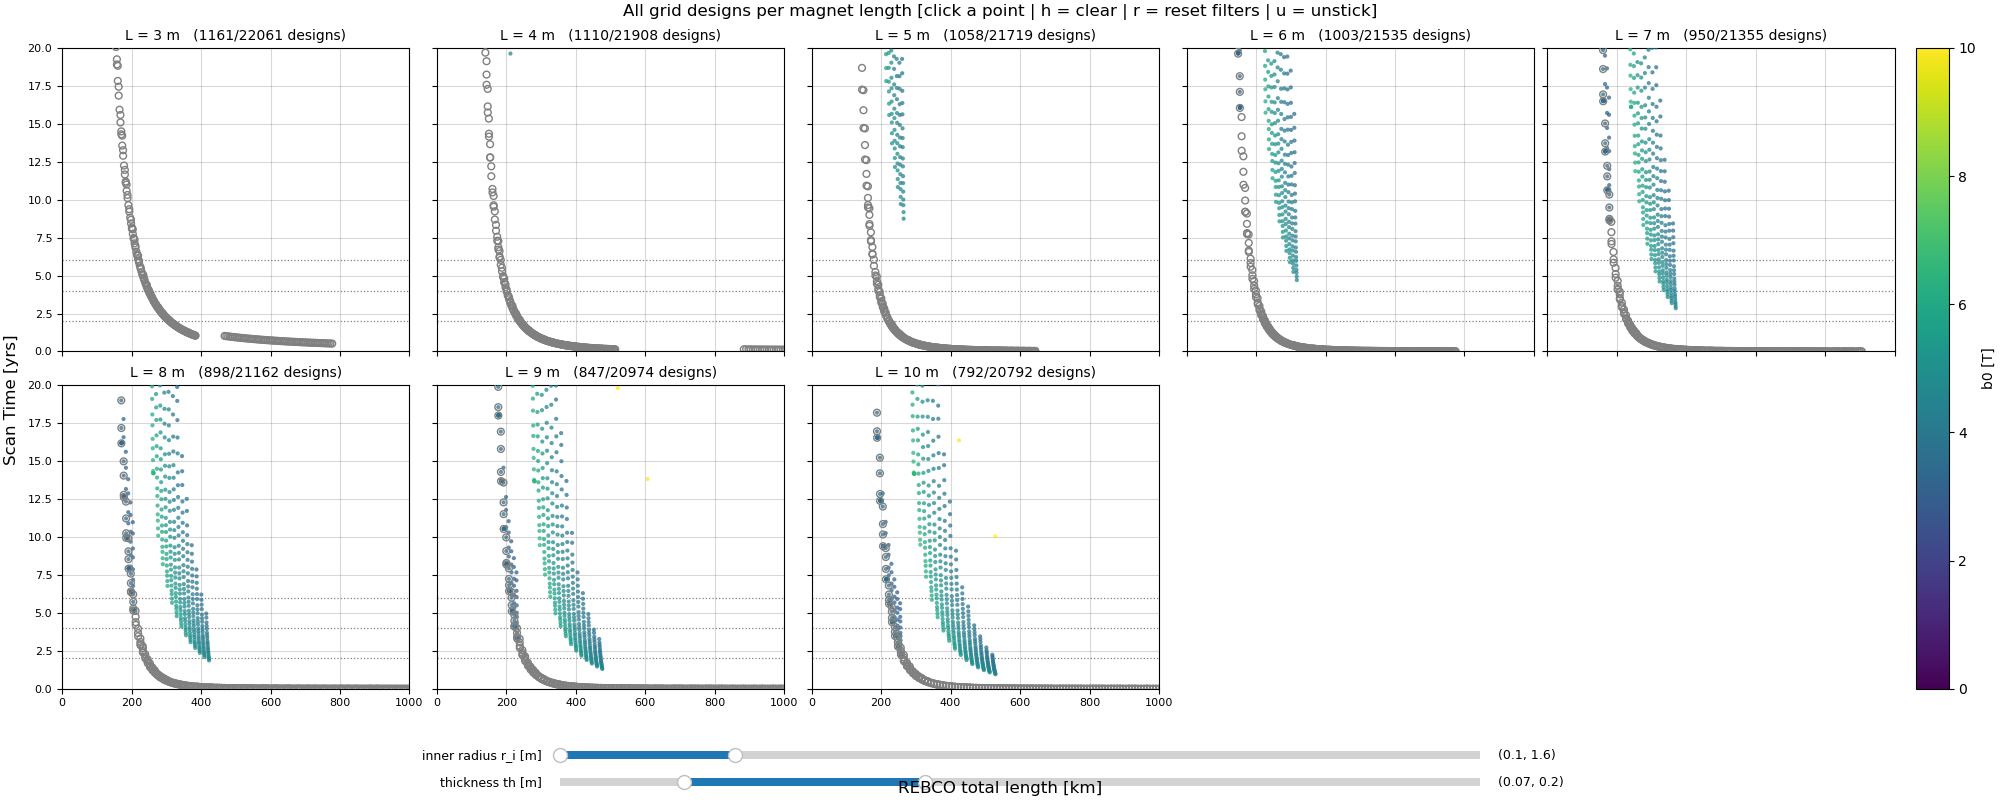

In [36]:
%matplotlib widget

# ---------------------------------------------------------------------------
# backend selection MUST happen before pyplot is imported
# ---------------------------------------------------------------------------
import matplotlib

_CURRENT = matplotlib.get_backend()
_NON_INTERACTIVE = ('agg', 'pdf', 'ps', 'svg', 'cairo', 'template')
if _CURRENT.lower() in _NON_INTERACTIVE or 'inline' in _CURRENT.lower():
    for _cand in ('qtagg', 'qt5agg', 'tkagg', 'macosx'):
        try:
            matplotlib.use(_cand, force=True)
            break
        except Exception:
            continue

import matplotlib.pyplot as plt
import matplotlib as mpl
import pandas as pd
import numpy as np
import glob
import os
import re
from matplotlib.widgets import RangeSlider

BACKEND = matplotlib.get_backend()
INTERACTIVE = not (BACKEND.lower() in _NON_INTERACTIVE or 'inline' in BACKEND.lower())
print(f"matplotlib backend: {BACKEND}"
      f"{'' if INTERACTIVE else '   <-- NOT interactive, clicking will not work'}")
if not INTERACTIVE:
    print("  In a notebook run  %matplotlib qt  (or install ipympl and use "
          "%matplotlib widget).  In a terminal install PyQt5:  pip install PyQt5")

# ----------------------------- user settings --------------------------------
Y_TOP        = 20
Y_BOTTOM     = 0
X_LIM        = (0.0, 1000.0)
SCAN_MIN, SCAN_MAX = 0, 100
KEEP_TIES    = False
TARGET_SCANS = (2, 4, 6)        # dotted horizontal guides

# ---- overview figure --------------------------------------------------------
NROWS, NCOLS       = 2, 5
APPLY_LIMITS       = True
SHARE_AXES         = True
SHOW_PARETO_POINTS = True     # open circles on the non-dominated designs
PARETO_COLOR       = 'gray'
PARETO_LW          = 1.0
FEASIBLE_ONLY      = False
CLICK_RADIUS_PX    = 15       # how close (in screen pixels) a click must be
PRINT_ALL_HITS     = False
MAKE_INDIVIDUAL    = False
SHOW_COLS          = ['b0', 'ri', 'th', 'solenoid_length_m', 'je_coil', 'je_tape',
                      'f_cu_add', 'f_struct', 'length_tape_km', 'scan']
OVERVIEW_NAME      = 'grid_points_all_lengths.png'

# ---- colour gradient on the cloud points ------------------------------------
COLOR_BY        = 'b0'            # column that drives the dot colour
POINT_CMAP      = plt.cm.viridis
POINT_ALPHA     = 0.75
COLOR_LIMITS    = (0.0, 10)       # fixed (vmin, vmax); None -> use percentiles
COLOR_CLIP_PCT  = (0.0, 100.0)    # only used when COLOR_LIMITS is None
FALLBACK_COLOR  = 'tab:blue'
CBAR_LABEL      = 'b0 [T]'

# ---- filters (static windows + optional sliders) ----------------------------
FILTER_SPECS = [
    ('ri', 'inner radius r_i [m]', (0, 1.6)),
    ('th', 'thickness th [m]',     (0.07, 0.2)),
]
USE_SLIDERS  = True       # False -> apply the fixed windows above, no widgets
SLIDER_H     = 0.020      # height of one slider in figure fractions
SLIDER_GAP   = 0.014      # vertical gap between two sliders
# -----------------------------------------------------------------------------

file_list = sorted(glob.glob('thickness_grids_L*.csv'))
if not file_list:
    raise SystemExit("No files matching 'thickness_grids_L*.csv' were found.")


def _fmt(k, v):
    if isinstance(v, (int, float, np.integer, np.floating)) and not isinstance(v, bool):
        return f'{k}: {v:.4g}'
    return f'{k}: {v}'


def _length_of(df, path):
    """Magnet length from the column if present, otherwise from the filename."""
    if 'solenoid_length_m' in df.columns and len(df):
        try:
            return float(df['solenoid_length_m'].iloc[0])
        except (TypeError, ValueError):
            pass
    mt = re.search(r'_L([0-9]+(?:\.[0-9]+)?)', os.path.basename(path))
    return float(mt.group(1)) if mt else float('nan')


def _pareto_xy(d):
    """Non-dominated designs: minimum scan time at increasing tape length."""
    dd = d[(d['scan'] >= SCAN_MIN) & (d['scan'] <= SCAN_MAX)]
    if not len(dd):
        return np.array([]), np.array([])
    dd = dd.sort_values(by=['length_tape_km', 'scan'])
    x = dd['length_tape_km'].to_numpy(dtype=float)
    y = dd['scan'].to_numpy(dtype=float)

    keep, min_y = [], float('inf')
    for i, yi in enumerate(y):
        if yi < min_y:
            keep.append(i)
            min_y = yi
        elif KEEP_TIES and yi == min_y:
            keep.append(i)
    if not keep:
        return np.array([]), np.array([])

    px, py = x[keep], y[keep]
    px_u, idx = np.unique(px, return_index=True)
    return px_u, py[idx]


# =============================================================================
# read every grid file
# =============================================================================
panels = []
for file_path in file_list:
    df_raw = pd.read_csv(file_path)
    if not {'length_tape_km', 'scan'} <= set(df_raw.columns):
        print(f"  skipping {os.path.basename(file_path)}: missing required columns")
        continue
    d = df_raw.dropna(subset=['length_tape_km', 'scan'])
    if FEASIBLE_ONLY and 'feasible' in d.columns:
        d = d[d['feasible'].astype(bool)]
    d = d.reset_index(drop=True)
    if not len(d):
        continue
    px, py = _pareto_xy(d)
    panels.append({'d': d, 'src': os.path.basename(file_path),
                   'L': _length_of(d, file_path), 'px': px, 'py': py})

panels.sort(key=lambda p: (np.isnan(p['L']), p['L']))

if not panels:
    raise SystemExit("\nNo usable thickness grids found for the overview figure.")

axes_registry = {}
_slider_ref = []          # keeps the widgets alive
_slider_axes = set()      # so on_click can ignore the widget axes

tip_cols = [c for c in SHOW_COLS if c in panels[0]['d'].columns]
absent = [c for c in SHOW_COLS if c not in panels[0]['d'].columns]
if absent:
    print(f"  tooltip: no column named {absent}")
    print(f"  available columns: {', '.join(panels[0]['d'].columns)}")

# ------------------- global colour scale for COLOR_BY ------------------------
HAVE_COLOR = all(COLOR_BY in p['d'].columns for p in panels)
cnorm, c_unique = None, np.array([])
if HAVE_COLOR:
    allc = np.concatenate([p['d'][COLOR_BY].to_numpy(dtype=float) for p in panels])
    allc = allc[np.isfinite(allc)]
    if allc.size == 0:
        HAVE_COLOR = False
    else:
        if COLOR_LIMITS is not None:
            lo, hi = float(COLOR_LIMITS[0]), float(COLOR_LIMITS[1])
        else:
            lo = float(np.percentile(allc, COLOR_CLIP_PCT[0]))
            hi = float(np.percentile(allc, COLOR_CLIP_PCT[1]))
            if lo == hi:                 # all values identical
                lo, hi = lo - 0.5, hi + 0.5
        cnorm = mpl.colors.Normalize(vmin=lo, vmax=hi)
        c_unique = np.unique(allc)
        n_out = int(np.count_nonzero((allc < lo) | (allc > hi)))
        print(f"  colouring dots by '{COLOR_BY}' over [{lo:.4g}, {hi:.4g}] "
              f"(data spans [{allc.min():.4g}, {allc.max():.4g}], "
              f"{c_unique.size} unique values, {n_out} saturated)")
if not HAVE_COLOR:
    print(f"  column '{COLOR_BY}' not usable -> flat colour {FALLBACK_COLOR}")

# ------------- work out the global range of every filter column --------------
filters = []          # [{'col', 'label', 'min', 'max', 'lo', 'hi'}, ...]
for col, label, fixed in FILTER_SPECS:
    if not all(col in p['d'].columns for p in panels):
        print(f"  filter '{col}' disabled: column missing in at least one grid file")
        continue
    vals = np.concatenate([p['d'][col].to_numpy(dtype=float) for p in panels])
    vals = vals[np.isfinite(vals)]
    if not vals.size:
        print(f"  filter '{col}' disabled: no finite values")
        continue
    vmin, vmax = float(vals.min()), float(vals.max())
    if vmin == vmax:                       # degenerate range breaks RangeSlider
        vmin, vmax = vmin - 0.5, vmax + 0.5
    lo, hi = fixed if fixed else (vmin, vmax)
    filters.append({'col': col, 'label': label, 'min': vmin, 'max': vmax,
                    'lo': float(lo), 'hi': float(hi)})
    print(f"  filter '{col}' spans [{vmin:.4g}, {vmax:.4g}]")


# =============================================================================
# ipympl mouse-grab guard
# =============================================================================
# RangeSlider calls canvas.grab_mouse() on press and only releases it when a
# button_release_event arrives.  Under %matplotlib widget that release is lost
# whenever the button is let go outside the figure, so canvas.mouse_grabber
# stays pinned to the first slider and the next press raises
#   RuntimeError: Another Axes already grabs mouse input
# Clearing any stale grab on every press fixes it: a real drag never produces a
# second press between its own press and release, so nothing legitimate is lost.
def _clear_grab(canvas):
    grabber = getattr(canvas, 'mouse_grabber', None)
    if grabber is not None:
        try:
            canvas.release_mouse(grabber)
        except Exception:
            pass
        canvas.mouse_grabber = None


def _release_stale_grab(event):
    _clear_grab(event.canvas)
    for w, _ in _slider_ref:
        w.drag_active = False


def _unstick_sliders():
    """Call this by hand if the sliders ever stop responding."""
    for fg in {i['fig'] for i in axes_registry.values()}:
        _clear_grab(fg.canvas)
    for w, _ in _slider_ref:
        w.drag_active = False
    print("mouse grab cleared - sliders should respond again")


def _connect(fig):
    """Attach the guard first, then the click/key handlers."""
    fig._cid_grab = fig.canvas.mpl_connect('button_press_event', _release_stale_grab)
    fig._cid_click = fig.canvas.mpl_connect('button_press_event', on_click)
    fig._cid_key = fig.canvas.mpl_connect('key_press_event', on_key)


def _draw_panel(ax, panel, small=True):
    """Draw one cloud on ax and register it for clicking/filtering."""
    d, L, src = panel['d'], panel['L'], panel['src']

    x_all = d['length_tape_km'].to_numpy(dtype=float)
    y_all = d['scan'].to_numpy(dtype=float)
    f_all = {f['col']: d[f['col']].to_numpy(dtype=float) for f in filters}
    c_all = d[COLOR_BY].to_numpy(dtype=float) if HAVE_COLOR else None

    if HAVE_COLOR:
        sc = ax.scatter(x_all, y_all, c=c_all, cmap=POINT_CMAP, norm=cnorm,
                        s=9 if small else 20, linewidth=0, alpha=POINT_ALPHA,
                        zorder=3, label='All grid designs')
    else:
        sc = ax.scatter(x_all, y_all, color=FALLBACK_COLOR,
                        s=9 if small else 20, linewidth=0, alpha=POINT_ALPHA,
                        zorder=3, label='All grid designs')

    if SHOW_PARETO_POINTS and len(panel['px']):
        ax.scatter(panel['px'], panel['py'], s=24 if small else 45,
                   facecolor='none', edgecolor=PARETO_COLOR, linewidth=PARETO_LW,
                   zorder=6, label='Pareto points')

    for t in TARGET_SCANS:
        ax.axhline(t, color='gray', linestyle=':', linewidth=0.9, zorder=2)

    tip = ax.annotate('', xy=(0, 0), xytext=(12, 12),
                      textcoords='offset points', annotation_clip=False,
                      bbox=dict(boxstyle='round,pad=0.35', fc='lightyellow',
                                ec='0.4', alpha=0.95),
                      arrowprops=dict(arrowstyle='->', color='0.4'),
                      fontsize=6.5 if small else 8, zorder=20, visible=False)
    mk, = ax.plot([], [], marker='o', markersize=10, markerfacecolor='none',
                  markeredgecolor='red', markeredgewidth=1.5,
                  linestyle='none', zorder=19, visible=False)

    axes_registry[ax] = {
        'd': d, 'src': src, 'L': L, 'fig': ax.figure,
        'sc': sc, 'tip': tip, 'mk': mk, 'small': small,
        'x_all': x_all, 'y_all': y_all, 'f_all': f_all, 'c_all': c_all,
        # visible subset - rewritten by _apply_filters()
        'x': x_all, 'y': y_all, 'idx': np.arange(len(x_all)),
    }

    if APPLY_LIMITS:
        ax.set_xlim(*X_LIM)
        ax.set_ylim(Y_BOTTOM, Y_TOP)
    ax.grid(True, linestyle='-', color='gray', alpha=0.3, zorder=0)


def _apply_filters(redraw=True):
    """Keep the designs that satisfy every active filter window."""
    for ax, info in axes_registry.items():
        m = np.ones(len(info['x_all']), dtype=bool)
        for f in filters:
            v = info['f_all'][f['col']]
            m &= np.isfinite(v) & (v >= f['lo']) & (v <= f['hi'])

        idx = np.flatnonzero(m)
        info['idx'] = idx
        info['x'] = info['x_all'][idx]
        info['y'] = info['y_all'][idx]

        # set_offsets needs an (N, 2) array, and an empty (0, 2) for no hits
        info['sc'].set_offsets(np.column_stack([info['x'], info['y']])
                               if len(idx) else np.empty((0, 2)))
        # the colour array must stay the same length as the offsets
        if info['c_all'] is not None:
            info['sc'].set_array(info['c_all'][idx] if len(idx)
                                 else np.empty(0, dtype=float))

        info['tip'].set_visible(False)
        info['mk'].set_visible(False)

        ax.set_title(f"L = {info['L']:g} m   "
                     f"({len(idx)}/{len(info['x_all'])} designs)",
                     fontsize=10 if info['small'] else 12)

    if redraw:
        for fg in {i['fig'] for i in axes_registry.values()}:
            fg.canvas.draw_idle()


def _on_slider(val, spec):
    spec['lo'], spec['hi'] = float(val[0]), float(val[1])
    _apply_filters()


def on_click(event):
    """Nearest visible point in pixel space - no picker needed."""
    if event.button != 1 or event.inaxes is None:
        return
    if event.inaxes in _slider_axes:          # clicks on the widgets are not data
        return
    info = axes_registry.get(event.inaxes)
    if info is None or not len(info['x']):
        return

    pts = event.inaxes.transData.transform(np.column_stack([info['x'], info['y']]))
    d2 = (pts[:, 0] - event.x) ** 2 + (pts[:, 1] - event.y) ** 2
    k = int(np.argmin(d2))

    if np.sqrt(d2[k]) > CLICK_RADIUS_PX:
        info['tip'].set_visible(False)
        info['mk'].set_visible(False)
        info['fig'].canvas.draw_idle()
        return

    near = info['idx'][np.flatnonzero(d2 <= CLICK_RADIUS_PX ** 2)]
    j = int(info['idx'][k])                       # row in the full dataframe
    row = info['d'].iloc[j]
    cols = [c for c in tip_cols if c in info['d'].columns] or list(info['d'].columns)

    info['tip'].set_text('\n'.join(_fmt(c, row[c]) for c in cols))
    info['tip'].xy = (info['x'][k], info['y'][k])
    info['tip'].set_visible(True)
    info['mk'].set_data([info['x'][k]], [info['y'][k]])
    info['mk'].set_visible(True)
    info['fig'].canvas.draw_idle()

    print(f"\n--- L = {info['L']:g} m, design #{j} "
          f"({len(near)} point(s) within {CLICK_RADIUS_PX} px), {info['src']} ---")
    if PRINT_ALL_HITS and len(near) > 1:
        print(info['d'].iloc[list(near)].to_string())
    else:
        print(row.to_string())


def on_key(event):
    if event.key in ('h', 'H'):
        for info in axes_registry.values():
            info['tip'].set_visible(False)
            info['mk'].set_visible(False)
        for fg in {i['fig'] for i in axes_registry.values()}:
            fg.canvas.draw_idle()
    elif event.key in ('r', 'R'):
        for w, spec in _slider_ref:
            w.set_val((spec['min'], spec['max']))   # triggers _on_slider
        if not _slider_ref:
            for spec in filters:
                spec['lo'], spec['hi'] = spec['min'], spec['max']
            _apply_filters()
    elif event.key in ('u', 'U'):
        _unstick_sliders()


# ----------------------------- overview grid ---------------------------------
n_slots = NROWS * NCOLS
n_rows = NROWS if len(panels) <= n_slots else int(np.ceil(len(panels) / NCOLS))
if len(panels) > n_slots:
    print(f"  {len(panels)} lengths do not fit in {NROWS}x{NCOLS}; "
          f"using {n_rows}x{NCOLS} instead")

figA, axesA = plt.subplots(n_rows, NCOLS, figsize=(4.0 * NCOLS, 4.0 * n_rows),
                           sharex=SHARE_AXES, sharey=SHARE_AXES,
                           constrained_layout=True)
axesA = np.atleast_1d(axesA).ravel()

for ax, panel in zip(axesA, panels):
    _draw_panel(ax, panel, small=True)
    ax.tick_params(labelsize=8)
for ax in axesA[len(panels):]:
    ax.set_visible(False)

figA.supxlabel('REBCO total length [km]')
figA.supylabel('Scan Time [yrs]')
figA.suptitle('All grid designs per magnet length '
              '[click a point | h = clear | r = reset filters | u = unstick]',
              fontsize=12)

# ------------------------- colorbar for the gradient -------------------------
if HAVE_COLOR:
    sm = mpl.cm.ScalarMappable(norm=cnorm, cmap=POINT_CMAP)
    sm.set_array([])
    cbar = figA.colorbar(sm, ax=list(axesA), fraction=0.020, pad=0.012)
    cbar.set_label(CBAR_LABEL)
    if 0 < c_unique.size <= 12:            # discrete sweep -> tick each value
        ticks = c_unique[(c_unique >= cnorm.vmin) & (c_unique <= cnorm.vmax)]
        if ticks.size:
            cbar.set_ticks(ticks)
    cbar.solids.set_alpha(1.0)

# the guard must be connected BEFORE the sliders build their own handlers,
# because matplotlib fires callbacks in connection order
_connect(figA)

# --------------------------- the filter sliders ------------------------------
if USE_SLIDERS and filters:
    n_f = len(filters)
    strip = 0.012 + n_f * (SLIDER_H + SLIDER_GAP)     # room at the bottom
    try:
        figA.get_layout_engine().set(rect=(0.0, strip, 1.0, 1.0 - strip))
    except Exception:
        figA.subplots_adjust(bottom=strip + 0.03)

    for n, spec in enumerate(filters):
        # first spec at the bottom, the next one above it
        y0 = 0.012 + (n_f - 1 - n) * (SLIDER_H + SLIDER_GAP)
        ax_sl = figA.add_axes([0.28, y0, 0.46, SLIDER_H])
        ax_sl.set_in_layout(False)          # keep it out of the auto layout
        _slider_axes.add(ax_sl)
        w = RangeSlider(ax_sl, spec['label'], spec['min'], spec['max'],
                        valinit=(spec['lo'], spec['hi']), valfmt='%.3g')
        w.label.set_fontsize(9)
        w.valtext.set_fontsize(9)
        w.on_changed(lambda val, s=spec: _on_slider(val, s))
        _slider_ref.append((w, spec))       # must stay referenced
    figA._filter_sliders = _slider_ref

_apply_filters(redraw=False)                # honour the fixed windows at start

figA.savefig(OVERVIEW_NAME, dpi=150)
print(f"\nOverview of {len(panels)} magnet lengths -> '{OVERVIEW_NAME}'")

# -------------------- optional full-size single panels -----------------------
if MAKE_INDIVIDUAL:
    for panel in panels:
        figI, axI = plt.subplots(figsize=(10, 8), constrained_layout=True)
        _draw_panel(axI, panel, small=False)
        axI.set_xlabel('REBCO total length [km]')
        axI.set_ylabel('Scan Time [yrs]')
        if HAVE_COLOR:
            smI = mpl.cm.ScalarMappable(norm=cnorm, cmap=POINT_CMAP)
            smI.set_array([])
            cbI = figI.colorbar(smI, ax=axI, fraction=0.035, pad=0.02)
            cbI.set_label(CBAR_LABEL)
            if 0 < c_unique.size <= 12:
                ticks = c_unique[(c_unique >= cnorm.vmin) & (c_unique <= cnorm.vmax)]
                if ticks.size:
                    cbI.set_ticks(ticks)
            cbI.solids.set_alpha(1.0)
        if axI.get_legend_handles_labels()[0]:
            axI.legend(loc='upper right')
        _connect(figI)
        figI.savefig(f"grid_points_L{panel['L']:g}m.png", dpi=150)
    _apply_filters(redraw=False)
    print(f"Individual per-length figures written for {len(panels)} lengths")

print("\nClick a point for its design vector; 'h' clears labels, "
      "'r' resets the filters, 'u' unsticks the sliders.")

plt.show()

# Scan-point overview — magnet parameters at fixed scan times

Reads the fixed-scan-time selection table and draws a 2x2 panel of design
quantities against total REBCO tape length, one line per target scan time,
coloured through `viridis` over the target range and optionally annotated with
each point's magnet length.

Rows are filtered to `match_status == 'in_window'` when `ONLY_IN_WINDOW` is set,
so fallback selections flagged `outside_window` and `no_match` stubs are
excluded; the retained count is printed. A non-fatal warning reports selections
with `converged == False`. Every panel column plus `X_COL` must be present or
the script exits before plotting.

Within a panel, points for one target year are ordered by tape length and
joined. Each point is a different magnet, so the line is a sweep through the
magnet family only to the extent that tape length is monotone in
`solenoid_length_m`.

> `ONLY_IN_WINDOW` is a no-op if `match_status` is missing, with no message.
> Confirm the "kept N/M rows" line appears.
>
> The `converged` warning under-counts: `astype(bool)` maps NaN and any
> non-empty string to True, so a column that round-trips as object dtype
> reports zero failures.
>
> Points are joined in tape-length order, not magnet-length order.
>
> `PANELS` is zipped against a fixed 2x2 grid; extra entries are dropped and
> unused axes are left blank.
>
> The x-axis label and panel titles are hard-coded for tape length and do not
> follow `X_COL`.

scan_time_points.csv: 32 rows, 79 columns
  kept 31/32 rows with match_status == 'in_window'
  line order: increasing solenoid_length_m (ties broken by length_tape_km)
  note: pancake_length_m ylim (50, 450) hides 1/31 point(s) (data spans 88.906 to 636.963)
  note: th ylim (0.06, 0.26) hides 1/31 point(s) (data spans 0.085 to 0.5)
  note: je_tape ylim (2800, 3600) hides 1/31 point(s) (data spans 2686.14 to 3539.92)


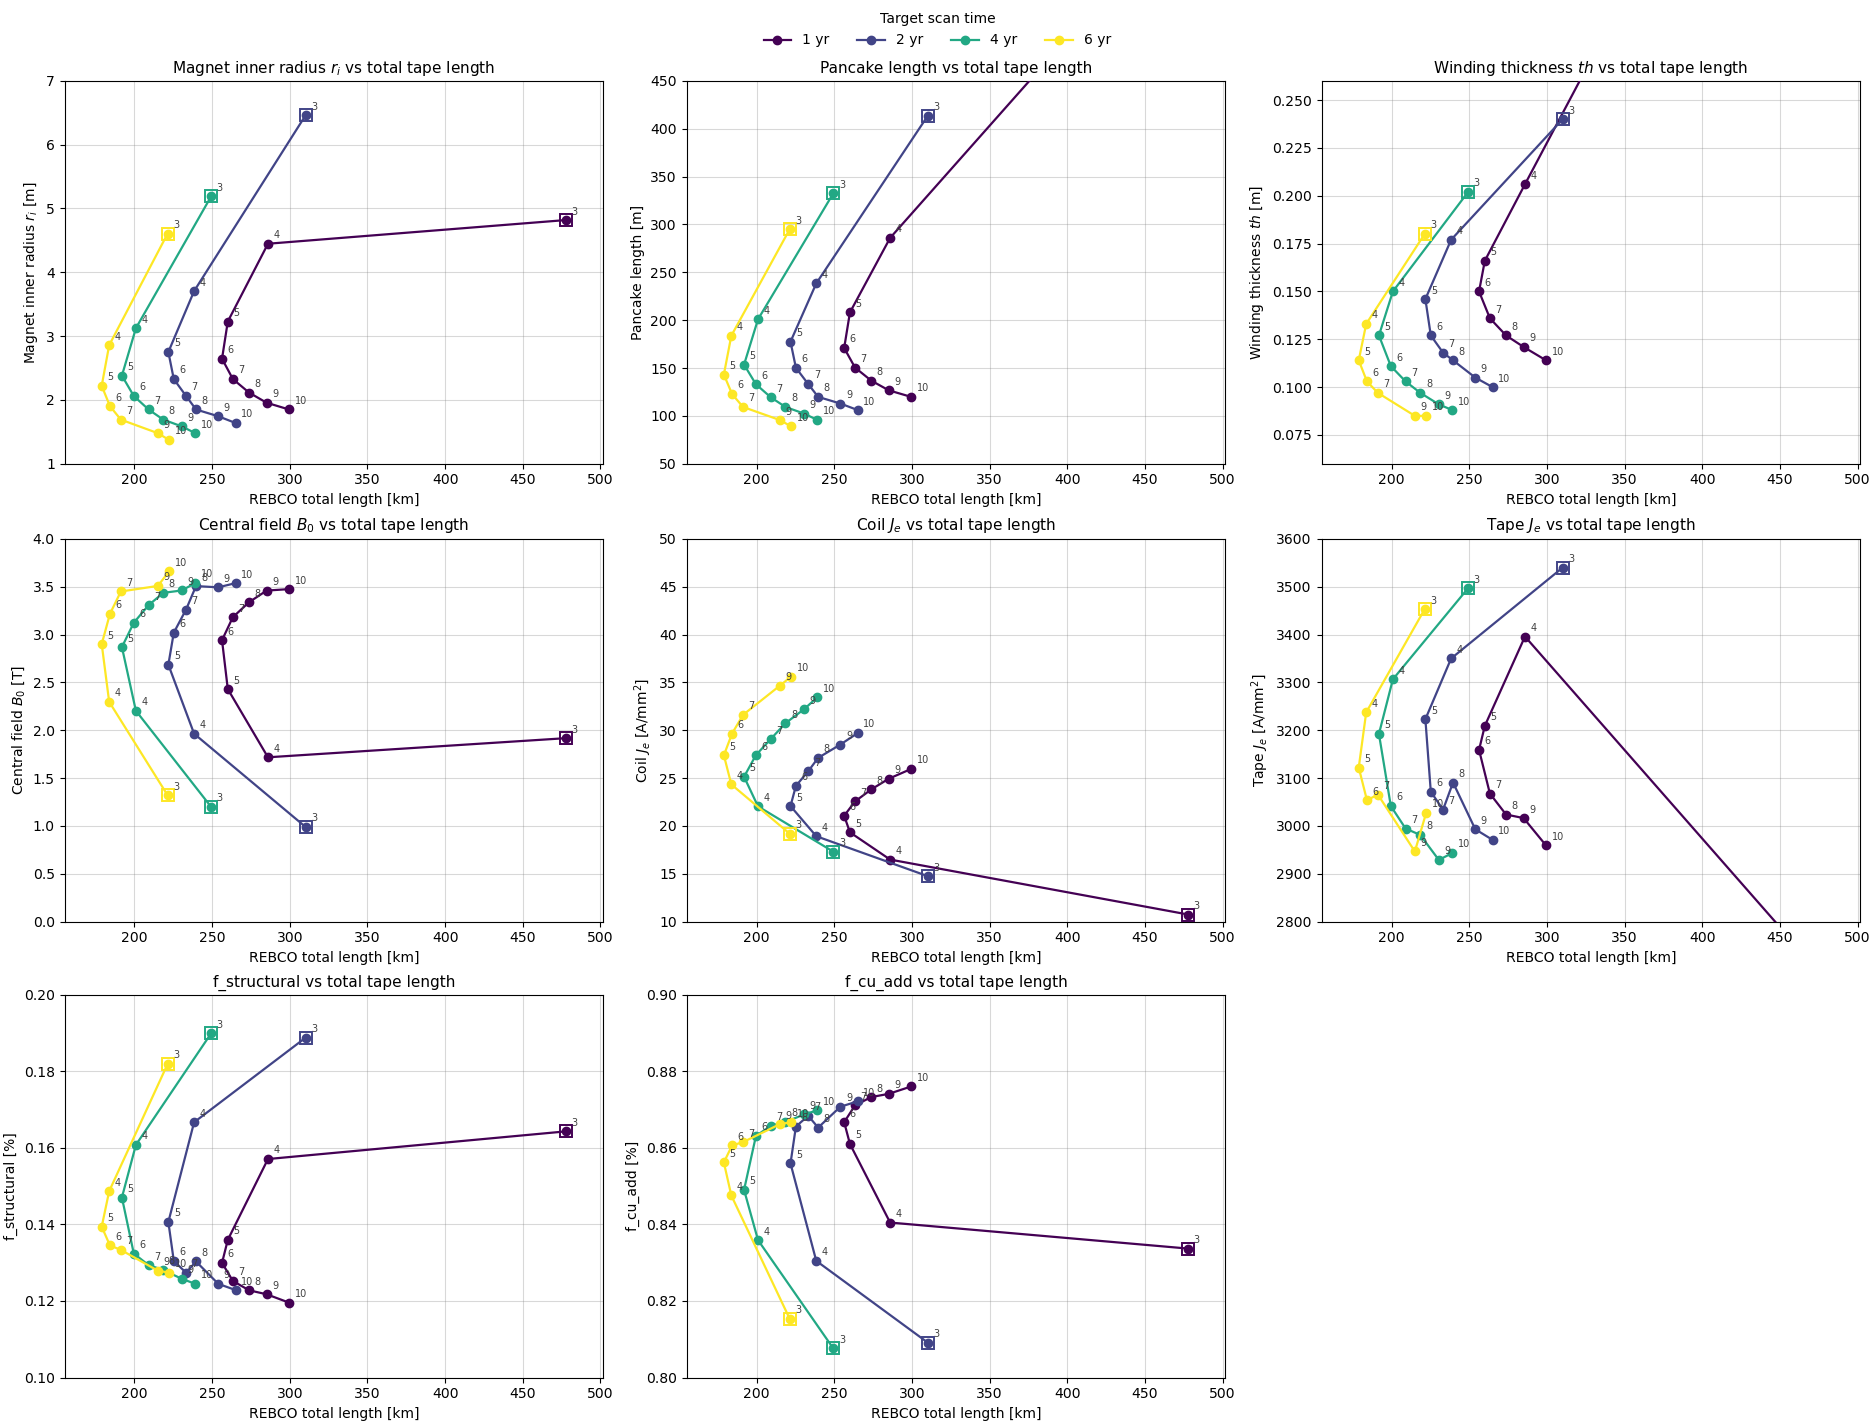

In [37]:
import math
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt

# ----------------------------- user settings --------------------------------
PATH            = 'scan_time_points.csv'
X_COL           = 'length_tape_km'          # "total length" on every x-axis
X_LABEL         = 'REBCO total length [km]' # must follow X_COL
LINE_ORDER_COL  = 'solenoid_length_m'       # connect markers in order of THIS column
MARK_LINE_START = True               # square marker on the shortest magnet
ONLY_IN_WINDOW  = True               # drop the flagged 'outside_window' fallbacks
STRICT_PANELS   = False              # True: missing panel column is fatal
ANNOTATE_LENGTH = True               # write the magnet length next to each marker
ANNOT_COLOR     = '0.25'             # dark grey; target colours are unreadable
CMAP            = plt.cm.viridis     # colour per target scan year
NCOLS           = 3
OUT             = 'scan_points_overview.png'
DPI             = 150

# ---- axis ranges ------------------------------------------------------------
# Default x-range shared by every panel (they all plot the same x-quantity).
# None -> autoscale; (lo, hi) -> hard limits, either entry may be None.
XLIM    = None                # e.g. (0, 250) or (0, None)
# Padding applied only to ends left on autoscale, as a fraction of the data
# span.  The length annotations sit up and to the right of each marker, so a
# little slack keeps them inside the axes.  None -> matplotlib default (5%).
MARGINS = 0.08

# (column, axis label, y-scale, ylim, xlim-override, y tick format)
#   ylim / xlim : None = autoscale, or a 2-tuple with optional None ends
#   tick format : None = matplotlib default, 'plain' = no 1e3 / offset notation
PANELS = [
    ('ri',               'Magnet inner radius $r_i$ [m]',  'linear', (1, 7)),
    ('pancake_length_m', 'Pancake length [m]',             'linear', (50, 450)),
    ('th',               'Winding thickness $th$ [m]',     'linear', (0.06, 0.26)),
    ('b0',               'Central field $B_0$ [T]',        'linear', (0, 4)),
    ('je_coil',          'Coil $J_e$ [A/mm$^2$]',          'linear',    (10, 50),
     None, 'plain'),
    ('je_tape',          'Tape $J_e$ [A/mm$^2$]',          'linear', (2800, 3600),
     None, 'plain'),
    ('f_struct',               'f_structural [%]',     'linear', (0.1, 0.2)), 
    ('f_cu_add',               'f_cu_add [%]',     'linear', (0.8, 0.9)), 
]
# -----------------------------------------------------------------------------


def _norm_panel(p):
    """Pad a panel entry out to (col, label, scale, ylim, xlim, yfmt)."""
    col   = p[0]
    label = p[1]
    scale = p[2] if len(p) > 2 and p[2] else 'linear'
    ylim  = p[3] if len(p) > 3 else None
    xlim  = p[4] if len(p) > 4 else XLIM
    yfmt  = p[5] if len(p) > 5 else None
    return (col, label, scale, ylim, xlim, yfmt)


PANELS = [_norm_panel(p) for p in PANELS]

df = pd.read_csv(PATH)
print(f"{PATH}: {len(df)} rows, {df.shape[1]} columns")

if X_COL not in df.columns:
    raise SystemExit(f"missing x column {X_COL!r}. Available: "
                     + ", ".join(df.columns))

missing = [c for c, *_ in PANELS if c not in df.columns]
if missing:
    msg = f"missing panel column(s) {missing}. Available: " + ", ".join(df.columns)
    if STRICT_PANELS:
        raise SystemExit(msg)
    print("  warning: " + msg)
    PANELS = [p for p in PANELS if p[0] in df.columns]
if not PANELS:
    raise SystemExit("no panel columns present")

if ONLY_IN_WINDOW:
    if 'match_status' in df.columns:
        n0 = len(df)
        df = df[df['match_status'] == 'in_window'].copy()
        print(f"  kept {len(df)}/{n0} rows with match_status == 'in_window'")
    else:
        print("  warning: match_status absent - ONLY_IN_WINDOW applied no filtering")

if 'converged' in df.columns:
    # astype(bool) would map NaN and the string 'False' to True
    bad = df['converged'].isin([False, 'False', 'false', 'FALSE', 0, '0'])
    n_bad = int(bad.sum()) + int(df['converged'].isna().sum())
    if n_bad:
        print(f"  warning: {n_bad} selected design(s) not converged or unlabelled")
    unconverged = bad | df['converged'].isna()
else:
    unconverged = pd.Series(False, index=df.index)

if len(df) == 0:
    raise SystemExit("nothing left to plot after filtering")

has_target = 'target_scan_yrs' in df.columns
has_len    = 'solenoid_length_m' in df.columns
targets    = np.sort(df['target_scan_yrs'].unique()) if has_target else [None]

# order the connecting line by magnet length when that column exists
if LINE_ORDER_COL in df.columns:
    SORT_KEYS = [LINE_ORDER_COL, X_COL]
    print(f"  line order: increasing {LINE_ORDER_COL} (ties broken by {X_COL})")
else:
    SORT_KEYS = [X_COL]
    print(f"  warning: {LINE_ORDER_COL!r} absent - line ordered by {X_COL}")

if has_target and len(targets) > 1:
    norm = mpl.colors.Normalize(vmin=float(np.min(targets)),
                                vmax=float(np.max(targets)))
    color_of = {t: CMAP(norm(t)) for t in targets}
else:
    color_of = {t: CMAP(0.45) for t in targets}

dup = df.duplicated(subset=[X_COL] + (['solenoid_length_m'] if has_len else []),
                    keep=False)
if dup.any():
    print(f"  note: {int(dup.sum())} rows share an (x, magnet length) coordinate; "
          "markers will overlap")


def _clipping_note(ycol, ylim):
    """Warn when the requested range pushes data off the panel."""
    if ylim is None:
        return
    y = df[ycol].to_numpy(dtype=float)
    y = y[np.isfinite(y)]
    if y.size == 0:
        return
    lo = -np.inf if ylim[0] is None else ylim[0]
    hi = np.inf if ylim[1] is None else ylim[1]
    n_out = int(((y < lo) | (y > hi)).sum())
    if n_out:
        print(f"  note: {ycol} ylim {ylim} hides {n_out}/{y.size} point(s) "
              f"(data spans {y.min():g} to {y.max():g})")


def _plain_yticks(ax):
    """Ordinary decimal tick labels: no 1e3 multiplier, no +3.0e3 offset."""
    major = mpl.ticker.ScalarFormatter()
    major.set_scientific(False)
    major.set_useOffset(False)
    ax.yaxis.set_major_formatter(major)
    if ax.get_yscale() == 'log':
        # a log axis spanning < ~2 decades has too few decade ticks to read,
        # so label the 2..9 minors as plain numbers too
        ax.yaxis.set_minor_locator(
            mpl.ticker.LogLocator(base=10.0, subs=np.arange(2, 10) * 0.1 * 10))
        minor = mpl.ticker.ScalarFormatter()
        minor.set_scientific(False)
        minor.set_useOffset(False)
        ax.yaxis.set_minor_formatter(minor)
        ax.tick_params(axis='y', which='minor', labelsize=7)


def _apply_limits(ax, ycol, ylim, xlim):
    """Set explicit ranges; pad the ends that stay on autoscale."""
    # x
    if xlim is None:
        if MARGINS is not None:
            ax.set_xmargin(MARGINS)
    else:
        ax.set_xlim(xlim[0], xlim[1])
        if xlim[0] is None or xlim[1] is None:
            if MARGINS is not None:
                ax.set_xmargin(MARGINS)
            ax.autoscale(enable=True, axis='x')   # re-run for the open end only
            ax.set_xlim(xlim[0], xlim[1])

    # y
    if ylim is None:
        if MARGINS is not None:
            ax.set_ymargin(MARGINS)
        return

    lo, hi = ylim
    if ax.get_yscale() == 'log':
        if lo is not None and lo <= 0:
            print(f"  note: ignoring non-positive lower ylim {lo} on log axis {ycol}")
            lo = None
        if hi is not None and hi <= 0:
            print(f"  note: ignoring non-positive upper ylim {hi} on log axis {ycol}")
            hi = None
    if lo is None and hi is None:
        if MARGINS is not None:
            ax.set_ymargin(MARGINS)
        return
    ax.set_ylim(lo, hi)
    if lo is None or hi is None:
        if MARGINS is not None:
            ax.set_ymargin(MARGINS)
        ax.autoscale(enable=True, axis='y')
        ax.set_ylim(lo, hi)


def draw(ax, ycol, ylabel, yscale, ylim=None, xlim=None, yfmt=None):
    """One panel: y-quantity vs total tape length, one line per target year.

    Markers keep their (tape length, y) position; the polyline joining them
    runs from the shortest magnet to the longest, so it may double back if the
    two lengths are not monotonically related.
    """
    drawn_any = False
    for t in targets:
        sub = (df if t is None else df[df['target_scan_yrs'] == t])
        sub = sub.sort_values(SORT_KEYS, kind='mergesort')
        # a NaN in x or y would break the line; drop those rows for the line
        sub = sub[sub[X_COL].notna() & sub[ycol].notna()]
        if len(sub) == 0:
            continue
        drawn_any = True
        ax.plot(sub[X_COL], sub[ycol], marker='o', markersize=6, linewidth=1.6,
                color=color_of[t],
                label='all points' if t is None else f'{t:g} yr', zorder=3)
        # square marks the first point of the series, i.e. the shortest magnet
        if MARK_LINE_START and len(SORT_KEYS) > 1:
            ax.plot(sub[X_COL].iloc[0], sub[ycol].iloc[0], linestyle='none',
                    marker='s', markersize=9, markerfacecolor='none',
                    markeredgecolor=color_of[t], markeredgewidth=1.4, zorder=4)
        # hollow overlay marks designs flagged not-converged
        bad = sub[unconverged.reindex(sub.index, fill_value=False)]
        if len(bad):
            ax.plot(bad[X_COL], bad[ycol], linestyle='none', marker='o',
                    markersize=9, markerfacecolor='none',
                    markeredgecolor='crimson', markeredgewidth=1.2, zorder=5)
        if ANNOTATE_LENGTH and has_len:
            for _, r in sub.iterrows():
                ax.annotate(f"{r['solenoid_length_m']:g}",
                            xy=(r[X_COL], r[ycol]), xytext=(4, 4),
                            textcoords='offset points', fontsize=7,
                            color=ANNOT_COLOR, zorder=6)

    if yscale == 'log':
        finite = df[ycol].to_numpy(dtype=float)
        finite = finite[np.isfinite(finite)]
        if finite.size and (finite > 0).all():
            ax.set_yscale('log')
        else:
            print(f"  note: {ycol} has non-positive values; keeping linear y-axis")

    # limits and formatters go last: set_yscale('log') resets both
    _clipping_note(ycol, ylim)
    _apply_limits(ax, ycol, ylim, xlim)
    if yfmt == 'plain':
        _plain_yticks(ax)

    ax.set_xlabel(X_LABEL)
    ax.set_ylabel(ylabel)
    ax.grid(True, linestyle='-', color='gray', alpha=0.3)
    ax.set_axisbelow(True)
    ax.set_title(f"{ylabel.split(' [')[0]} vs total tape length", fontsize=11)
    if not drawn_any:
        ax.text(0.5, 0.5, f"no finite {ycol}", transform=ax.transAxes,
                ha='center', va='center', fontsize=9, color='0.4')


nrows = math.ceil(len(PANELS) / NCOLS)
fig, axes = plt.subplots(nrows, NCOLS,
                         figsize=(6.25 * NCOLS, 4.75 * nrows),
                         constrained_layout=True, squeeze=False)
flat = axes.ravel()
for ax, panel in zip(flat, PANELS):
    draw(ax, *panel)
for ax in flat[len(PANELS):]:
    fig.delaxes(ax)

handles, labels = flat[0].get_legend_handles_labels()
if handles:
    fig.legend(handles, labels,
               title='Target scan time' if has_target else None,
               loc='outside upper center', ncol=min(len(labels), 6),
               frameon=False)


fig.savefig(OUT, dpi=DPI, bbox_inches='tight')

plt.show()

In [ ]:
import importlib
import math
import solenoid_lib


importlib.reload(solenoid_lib)


from solenoid_lib import scan_time, dB_to_eta

# Magnet / bore geometry
B0_baseline = 18          # T
l_bore      = 8.5         # m
d_bore      = 0.090       # m
V_m3        = math.pi * (d_bore / 2)**2 * l_bore   # bore volume [m^3]
print(f"Bore volume: {V_m3:.4f} m^3")

s_per_year = 365.25 * 24 * 3600


print(f"{'Scenario':<40} {'Expected':>10}  {'DFSZ':>10} {'Ratio':>10}")
print("-" * 74)

scenarios = [
    (16, 10, 20e6, -20, 6.2,  'Baseline'),
    (29, 10, 20e6, -5,  3.2,  'Stronger magnet + higher noise'),
    (16,  8, 20e6, -25, 7.3,  'Lower noise + lower volume'),
    (16, 17,  2e6, -20, 10.6, 'Higher volume + lower Q'),
    (26, 10,  2e6, -20, 8.9,  'Stronger magnet + lower Q'),
    (B0_baseline, V_m3, 20e6, -20, 2.24,  'CORE-GUT')
]

for (B0, V_m3, Q, eta_dB, expected, name) in scenarios:
    eta_A  = dB_to_eta(eta_dB)
    t_dfsz = scan_time(B0, V_m3, Q=Q, eta_A=eta_A, model='DFSZ')
    ratio  = expected / t_dfsz
    print(f"{name:<40} {expected:>10.1f} {t_dfsz:>10.2f} {ratio:>10.3f}")